In [12]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================

from pathlib import Path
import pandas as pd

print("Libraries imported successfully.")

Libraries imported successfully.


In [13]:
# ============================================================
# CELL 2: SET FOLDER PATH
# ============================================================

folder_path = Path("/Users/elsiekaaya/PycharmProjects/Data")

print("Folder path set to:")
print(folder_path)

Folder path set to:
/Users/elsiekaaya/PycharmProjects/Data


In [14]:
# ============================================================
# CELL 3: CHECK WHETHER FOLDER EXISTS
# ============================================================

if not folder_path.exists():
    raise FileNotFoundError(f"Folder not found: {folder_path}")

if not folder_path.is_dir():
    raise NotADirectoryError(f"This path is not a folder: {folder_path}")

print("Folder exists and is accessible.")

Folder exists and is accessible.


In [15]:
# ============================================================
# CELL 4: FIND ALL CSV FILES IN THE FOLDER
# ============================================================

csv_files = list(folder_path.glob("*.csv"))

if len(csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in folder: {folder_path}")

print(f"Number of CSV files found: {len(csv_files)}")
print("\nFiles found:")

for file in csv_files:
    print("-", file.name)

Number of CSV files found: 5

Files found:
- clinical_assessments.csv
- participants.csv
- daily_data.csv
- final_outcomes.csv
- weekly_summary.csv


In [16]:
# ============================================================
# CELL 5: LOAD ALL CSV FILES INTO A DICTIONARY
# ============================================================

dataframes = {}

for file in csv_files:
    dataset_name = file.stem  # file name without .csv
    dataframes[dataset_name] = pd.read_csv(file)

    print(f"Loaded: {file.name}")
    print(f"Dataset name: {dataset_name}")
    print(f"Shape: {dataframes[dataset_name].shape}")
    print("-" * 50)

print("All CSV files loaded successfully.")

Loaded: clinical_assessments.csv
Dataset name: clinical_assessments
Shape: (7000, 12)
--------------------------------------------------
Loaded: participants.csv
Dataset name: participants
Shape: (1000, 23)
--------------------------------------------------
Loaded: daily_data.csv
Dataset name: daily_data
Shape: (85000, 36)
--------------------------------------------------
Loaded: final_outcomes.csv
Dataset name: final_outcomes
Shape: (1000, 11)
--------------------------------------------------
Loaded: weekly_summary.csv
Dataset name: weekly_summary
Shape: (13000, 40)
--------------------------------------------------
All CSV files loaded successfully.


In [18]:
# ============================================================
# CELL 6: PREVIEW ALL LOADED DATASETS
# ============================================================

for name, df in dataframes.items():
    print("\n" + "=" * 60)
    print(f"Dataset name: {name}")
    print(f"Shape: {df.shape}")
    print("=" * 60)
    display(df.head())


Dataset name: clinical_assessments
Shape: (7000, 12)


,participant_id,assessment_date,week,PHQ_score,change_from_baseline,percent_change_from_baseline,response_status,remission_status,worsening_status,treatment_review_decision,trajectory_group,life_event_in_prior_7d
0,0,01/01/2024,0,16.7,0.7,-4.37,non_responder,no,no,NaN,non_responder,0
1,0,15/01/2024,2,15.2,-0.8,5.00,non_responder,no,no,NaN,non_responder,0
2,0,29/01/2024,4,16.4,0.4,-2.50,non_responder,no,no,adjust,non_responder,0
3,0,12/02/2024,6,14.3,-1.7,10.62,non_responder,no,no,NaN,non_responder,1
4,0,26/02/2024,8,14.7,-1.3,8.13,non_responder,no,no,adjust,non_responder,0



Dataset name: participants
Shape: (1000, 23)


,participant_id,age,sex,ethnicity,site_region,time_zone,device_phone_os,wearable_type,baseline_phq_score,initial_severity_group,adherence_risk_profile,treatment_type,treatment_start_date,final_week12_PHQ_score,final_change_from_baseline,final_percent_change_from_baseline,final_response_status,final_remission_status,final_worsening_status,week12_treatment_review_decision,time_to_response_weeks,sustained_improvement_flag,trajectory_group_derived
0,0,42,female,African,Nairobi,Africa/Nairobi,iOS,Samsung Watch,16,moderately_severe,high,combined,01/01/2024,13.8,-2.2,13.75,non_responder,no,no,adjust,NaN,0,non_responder
1,1,45,female,East Asian,Berlin,Europe/Berlin,iOS,Garmin,14,moderate,medium,combined,01/01/2024,5.2,-8.8,62.86,responder,no,no,maintain,10.0,1,non_responder
2,2,40,female,South Asian,Dar es Salaam,Africa/Dar_es_Salaam,Android,Xiaomi Band,14,moderate,medium,combined,01/01/2024,2.9,-11.1,79.29,responder,yes,no,maintain,6.0,1,delayed_responder
3,3,62,female,Latino/Hispanic,London,Europe/London,Android,Apple Watch,14,moderate,high,combined,01/01/2024,4.2,-9.8,70.00,responder,yes,no,maintain,8.0,1,delayed_responder
4,4,46,female,East Asian,Dar es Salaam,Africa/Dar_es_Salaam,Android,Samsung Watch,8,mild,low,combined,01/01/2024,0.0,-8.0,100.00,responder,yes,no,maintain,2.0,1,early_responder



Dataset name: daily_data
Shape: (85000, 36)


,participant_id,date,study_day,week,day_of_week,is_weekend,life_event_flag,ema_anhedonia,ema_energy,ema_stress,sleep_efficiency,WASO_min,avg_hrv,resting_hr,steps,sedentary_min,time_at_home,location_entropy,distance_traveled_km,bedtime_variability_min,wake_variability_min,screen_time,night_screen_time,app_sessions_total,app_sessions_social,unique_contacts,calls_total,call_duration_min,med_adherence,therapy_adherence,overall_adherence,gps_missing_pct,hr_missing_pct,gps_outage_flag,wearable_nonwear_flag,passive_dropout_flag
0,0,01/01/2024,0,0,0,0,0,2,2,2,0.766,29.9,25.7,69.4,6544,709,12.43,0.864,7.44,55.4,55.7,5.01,2.08,46,15,3,2,12.2,0.687,0.659,0.673,0.246,0.507,0,0,0
1,0,02/01/2024,1,0,1,0,0,3,2,3,0.740,38.5,28.8,71.1,5945,726,13.82,1.172,7.57,63.8,66.2,5.09,2.30,50,16,2,2,14.3,0.676,0.711,0.694,0.110,0.377,0,0,0
2,0,03/01/2024,2,0,2,0,0,2,3,2,0.737,46.9,28.0,70.4,2945,657,15.04,1.095,5.41,59.9,66.0,5.88,2.33,51,13,3,3,13.5,0.721,0.661,0.691,0.238,0.337,0,0,0
3,0,04/01/2024,3,0,3,0,0,3,3,3,0.702,42.7,33.7,70.4,4091,697,13.42,1.167,6.15,62.8,64.6,5.72,2.07,46,13,3,3,13.7,0.654,0.701,0.677,0.353,0.337,0,0,0
4,0,05/01/2024,4,0,4,0,0,2,2,2,0.701,47.7,37.1,71.0,4836,733,12.86,1.092,6.65,74.8,63.6,5.68,2.19,51,8,3,3,11.8,0.565,0.540,0.553,0.260,0.325,0,0,0



Dataset name: final_outcomes
Shape: (1000, 11)


,participant_id,final_week12_PHQ_score,final_change_from_baseline,final_percent_change_from_baseline,final_response_status,final_remission_status,final_worsening_status,week12_treatment_review_decision,time_to_response_weeks,sustained_improvement_flag,trajectory_group_derived
0,0,13.8,-2.2,13.75,non_responder,no,no,adjust,NaN,0,non_responder
1,1,5.2,-8.8,62.86,responder,no,no,maintain,10.0,1,non_responder
2,2,2.9,-11.1,79.29,responder,yes,no,maintain,6.0,1,delayed_responder
3,3,4.2,-9.8,70.00,responder,yes,no,maintain,8.0,1,delayed_responder
4,4,0.0,-8.0,100.00,responder,yes,no,maintain,2.0,1,early_responder



Dataset name: weekly_summary
Shape: (13000, 40)


,participant_id,week,sleep_efficiency_7d_mean,WASO_min_7d_mean,steps_7d_mean,sedentary_min_7d_mean,avg_hrv_7d_mean,resting_hr_7d_mean,time_at_home_7d_mean,location_entropy_7d_mean,distance_traveled_km_7d_mean,bedtime_variability_7d_mean,wake_variability_7d_mean,screen_time_7d_mean,night_screen_time_7d_mean,app_sessions_total_7d_mean,app_sessions_social_7d_mean,unique_contacts_7d_mean,calls_total_7d_mean,call_duration_7d_mean,med_adherence_7d_mean,therapy_adherence_7d_mean,overall_adherence_7d_mean,gps_missing_pct_7d_mean,hr_missing_pct_7d_mean,ema_anhedonia_7d_mean,ema_energy_7d_mean,ema_stress_7d_mean,life_event_days_in_week,gps_outage_days_in_week,wearable_nonwear_days_in_week,passive_dropout_days_in_week,sleep_efficiency_7d_std,steps_7d_std,avg_hrv_7d_std,resting_hr_7d_std,screen_time_7d_std,night_screen_time_7d_std,bedtime_variability_7d_std,wake_variability_7d_std
0,0,0,0.722286,43.742857,5017.000000,718.857143,32.585714,71.000000,12.987143,1.057571,6.317143,66.557143,64.171429,5.284286,2.190000,50.714286,12.428571,2.857143,2.714286,14.242857,0.649857,0.650000,0.650000,0.248286,0.371000,2.571429,2.285714,2.571429,0,0,0,0,0.025513,1236.460001,5.060115,1.093923,0.469356,0.111505,8.106758,3.942383
1,0,1,0.671286,46.614286,5912.428571,725.285714,39.542857,72.942857,13.432857,1.031571,6.660000,86.885714,63.600000,4.760000,2.045714,53.000000,12.000000,3.142857,2.857143,14.657143,0.690714,0.635143,0.663000,0.264143,0.317000,2.428571,2.285714,2.000000,0,0,0,0,0.017153,935.660704,1.573592,0.960655,0.492307,0.183472,6.233626,3.782856
2,0,2,0.696429,48.028571,6438.571429,664.571429,36.871429,72.242857,13.482857,0.987571,5.858571,74.985714,80.414286,5.292857,2.387143,53.142857,9.857143,2.571429,1.428571,12.028571,0.577000,0.453571,0.515143,0.292000,0.292714,2.142857,2.714286,2.428571,0,0,0,0,0.020082,437.900239,2.448615,2.751277,0.293071,0.129321,3.686203,4.269437
3,0,3,0.741857,47.028571,5816.714286,701.428571,39.571429,75.057143,12.665714,1.300286,4.372857,78.085714,71.814286,5.068571,2.484286,59.285714,11.428571,3.000000,2.285714,9.642857,0.483857,0.441286,0.462429,0.292000,0.301571,2.142857,2.428571,2.285714,0,1,0,0,0.014147,841.549704,2.392846,3.310014,0.286090,0.258448,4.157094,5.139854
4,0,4,0.738286,42.557143,5789.571429,713.428571,36.971429,71.585714,13.155714,1.202571,4.672857,64.771429,71.557143,4.907143,2.280000,53.000000,7.285714,3.000000,2.142857,14.614286,0.435000,0.411286,0.423286,0.285857,0.310857,2.000000,2.428571,2.000000,0,0,0,0,0.006343,1053.531657,4.015684,1.402888,0.382000,0.254296,4.612922,2.739134


In [19]:
# ============================================================
# CELL 7: SHOW DATASET NAMES
# ============================================================

print("You can access the datasets using these names:")

for name in dataframes.keys():
    print(f'dataframes["{name}"]')

You can access the datasets using these names:
dataframes["clinical_assessments"]
dataframes["participants"]
dataframes["daily_data"]
dataframes["final_outcomes"]
dataframes["weekly_summary"]


In [22]:
# ============================================================
# CELL 8: ASSIGN DATASETS TO INDIVIDUAL VARIABLES
# ============================================================

# Change the names inside dataframes["..."] to match your exact file names

participants = dataframes["participants"]
daily_data = dataframes["daily_data"]
clinical_assessments = dataframes["clinical_assessments"]
final_outcomes = dataframes["final_outcomes"]
weekly_summary = dataframes ["weekly_summary"]

print("Datasets assigned successfully.")

Datasets assigned successfully.


In [27]:
print(dataframes.keys())

dict_keys(['clinical_assessments', 'participants', 'daily_data', 'final_outcomes', 'weekly_summary'])


In [28]:
participants = dataframes["participants"]
daily_data = dataframes["daily_data"]
clinical_assessments = dataframes["clinical_assessments"]
final_outcomes = dataframes["final_outcomes"]
weekly_summary = dataframes["weekly_summary"]

In [29]:
print("participants:", participants.shape)
print("daily_data:", daily_data.shape)
print("clinical_assessments:", clinical_assessments.shape)
print("final_outcomes:", final_outcomes.shape)
print("weekly_summary:", weekly_summary.shape)

participants: (1000, 23)
daily_data: (85000, 36)
clinical_assessments: (7000, 12)
final_outcomes: (1000, 11)
weekly_summary: (13000, 40)


In [30]:
# ============================================================
# CELL 9: CONFIRM DATASET SHAPES
# ============================================================

print("participants:", participants.shape)
print("daily_data:", daily_data.shape)
print("clinical_assessments:", clinical_assessments.shape)
print("final_outcomes:", final_outcomes.shape)
print("weekly_summary:", weekly_summary.shape)

participants: (1000, 23)
daily_data: (85000, 36)
clinical_assessments: (7000, 12)
final_outcomes: (1000, 11)
weekly_summary: (13000, 40)


In [37]:
# ============================================================
# CELL 1: IMPORT PACKAGES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [38]:
# ============================================================
# CELL 2: SET GLOBAL PLOT STYLE
# ============================================================

sns.set_theme(style="darkgrid", context="talk")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

plt.rcParams["axes.facecolor"] = "#111111"
plt.rcParams["figure.facecolor"] = "#111111"
plt.rcParams["axes.edgecolor"] = "#444444"
plt.rcParams["axes.labelcolor"] = "#EAEAEA"
plt.rcParams["xtick.color"] = "#D9D9D9"
plt.rcParams["ytick.color"] = "#D9D9D9"
plt.rcParams["text.color"] = "#F2F2F2"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.frameon"] = True
plt.rcParams["legend.facecolor"] = "#1A1A1A"
plt.rcParams["legend.edgecolor"] = "#444444"
plt.rcParams["grid.color"] = "#444444"
plt.rcParams["grid.alpha"] = 0.6
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Plot style applied successfully.")

Plot style applied successfully.


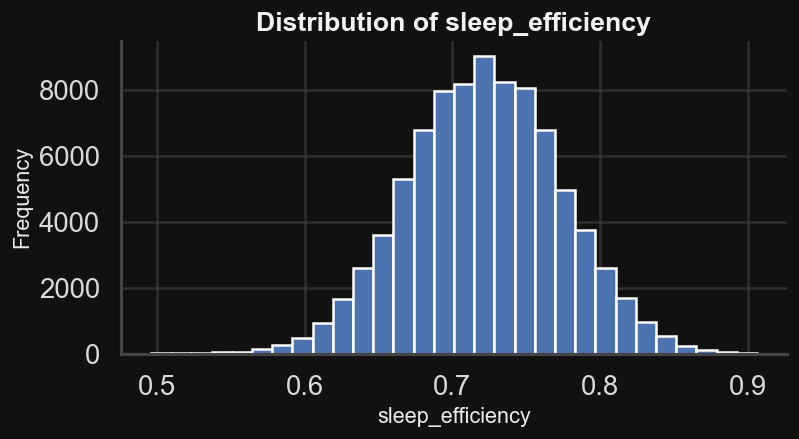

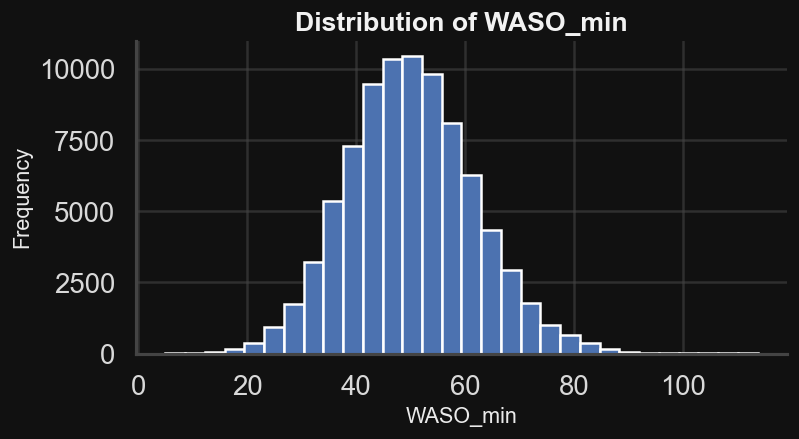

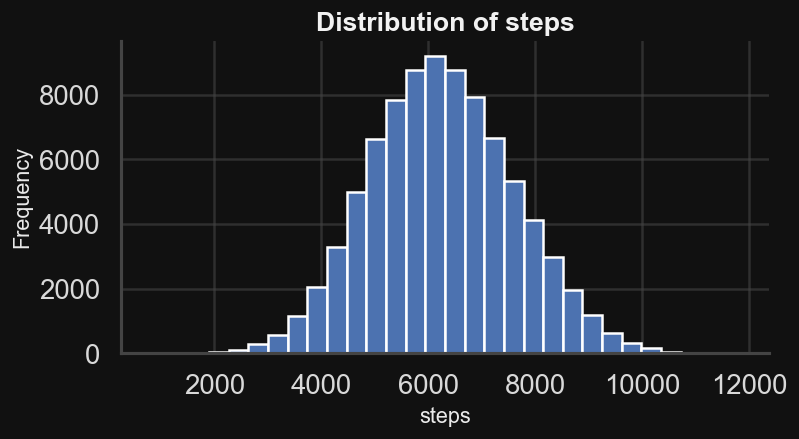

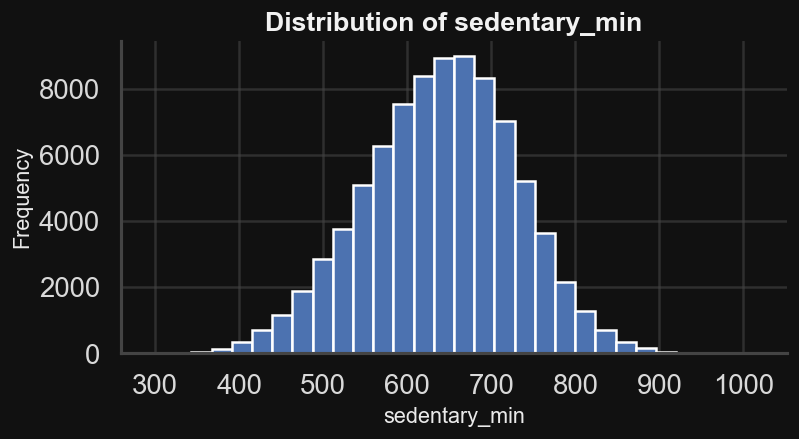

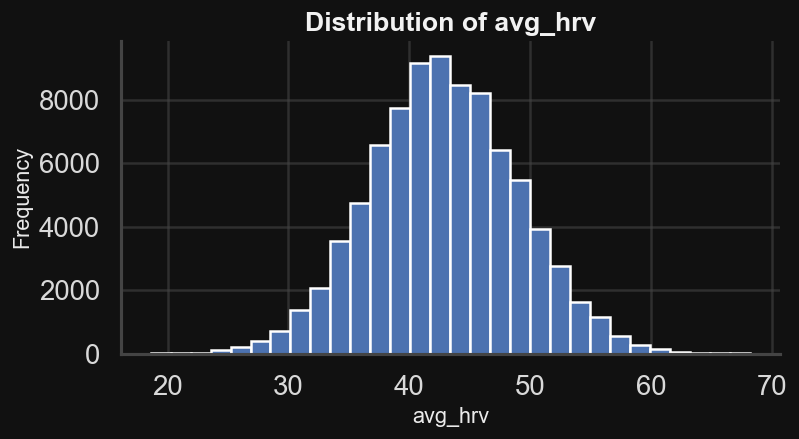

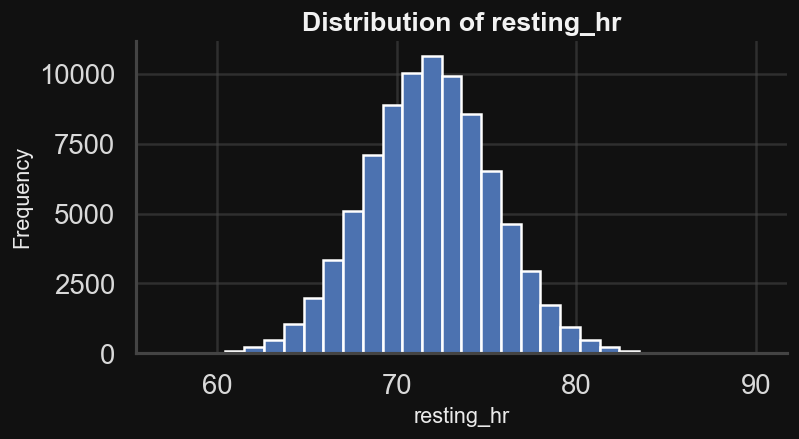

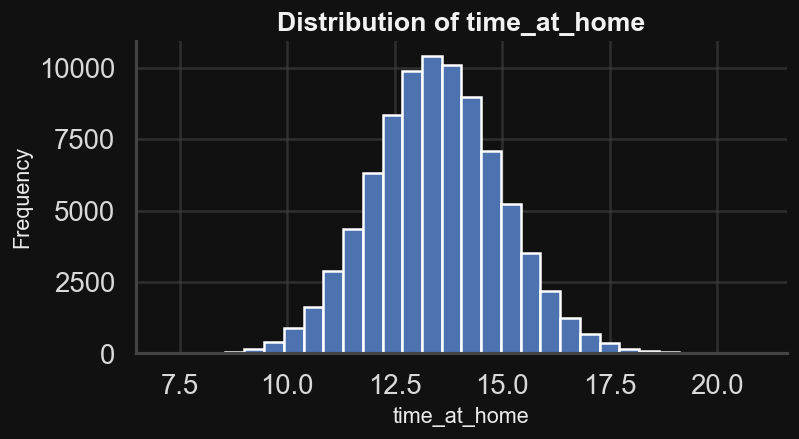

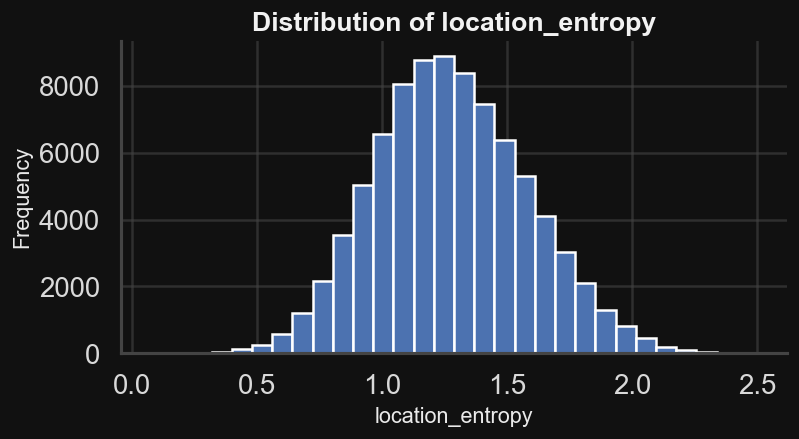

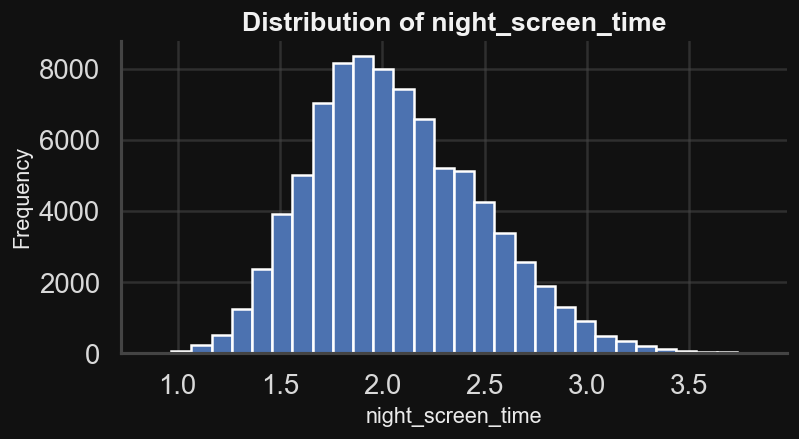

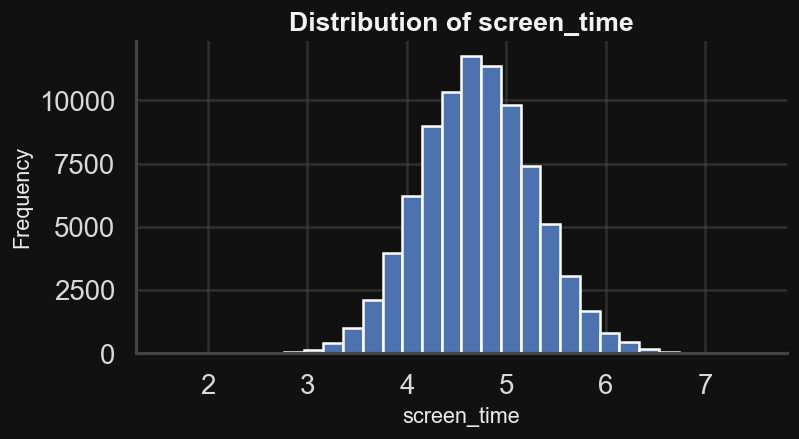

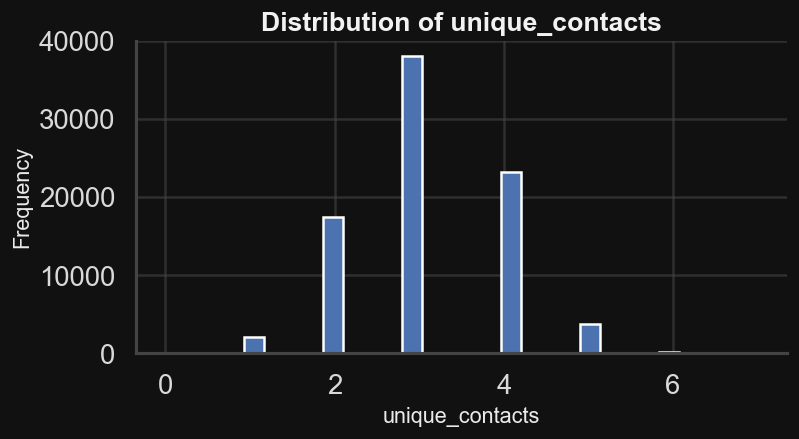

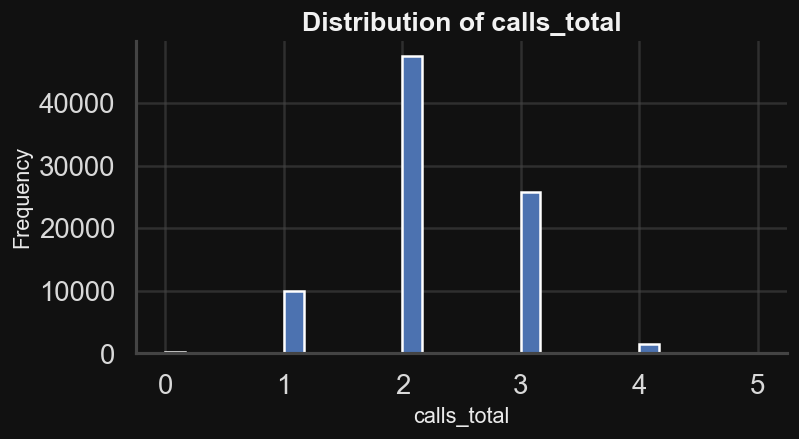

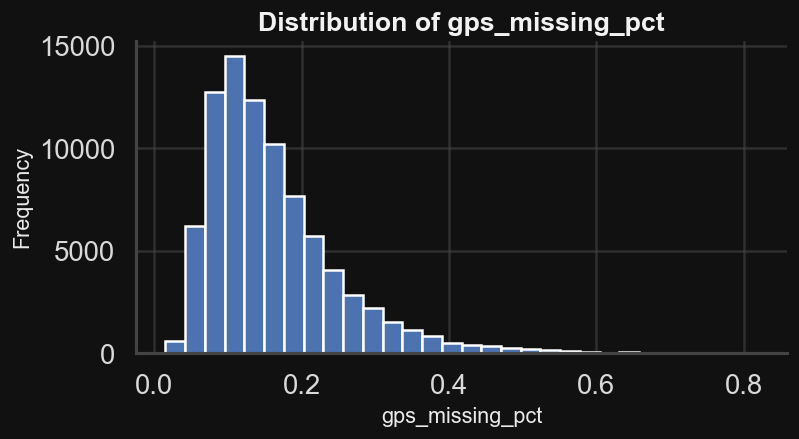

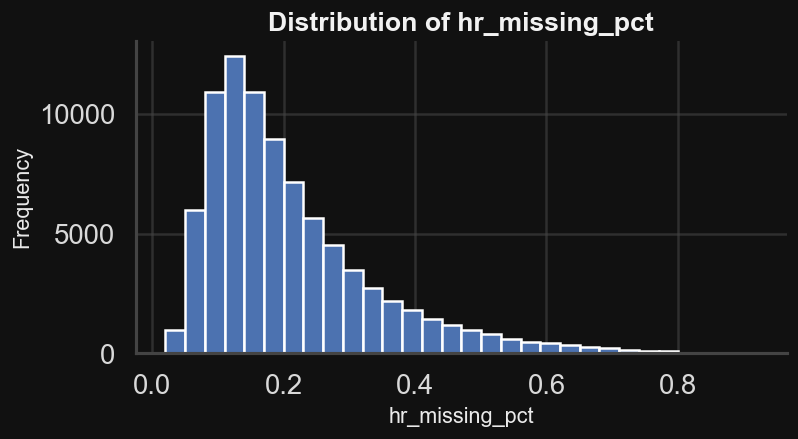

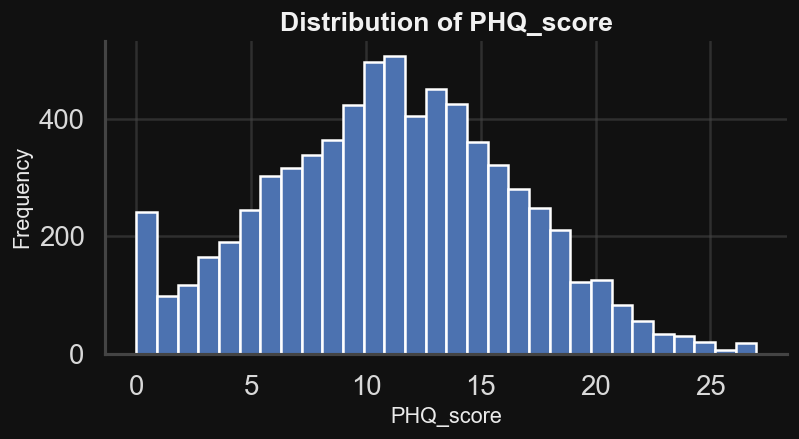

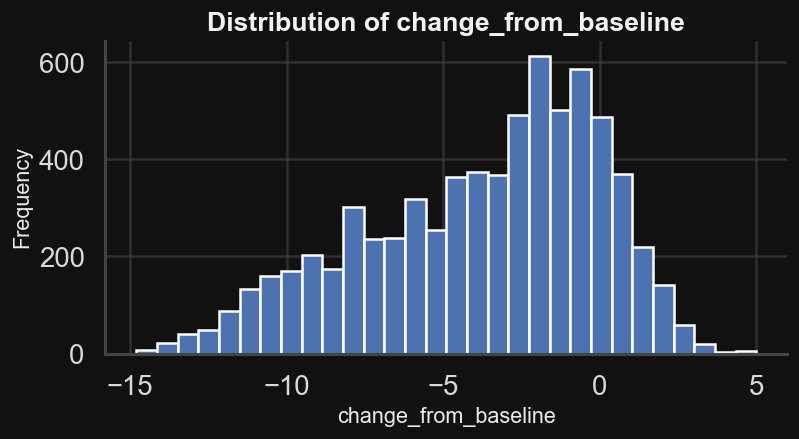

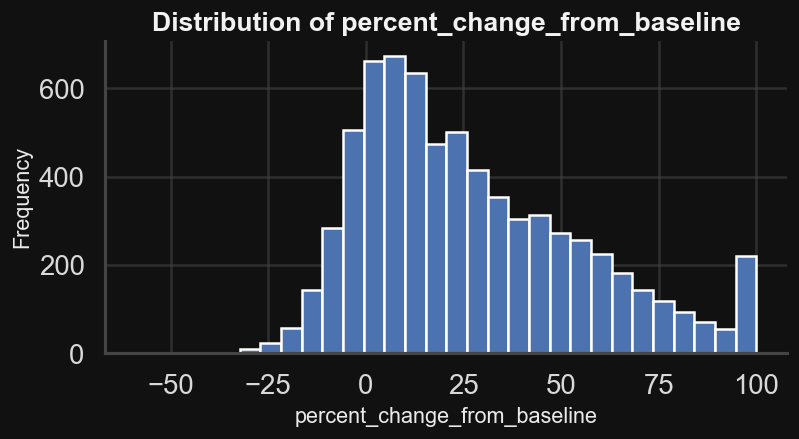

Distribution plots completed and saved in outputs/plots.


In [54]:
# ============================================================
# CELL 3: DISTRIBUTION PLOTS
# ============================================================
# Purpose:
# To visually inspect whether key behavioral, physiological,
# and clinical variables show plausible distributions.
# ============================================================

# Key variables from daily data
daily_distribution_vars = [
    "sleep_efficiency",
    "WASO_min",
    "steps",
    "sedentary_min",
    "avg_hrv",
    "resting_hr",
    "time_at_home",
    "location_entropy",
    "night_screen_time",
    "screen_time",
    "unique_contacts",
    "calls_total",
    "call_duration",
    "gps_missing_pct",
    "hr_missing_pct"
]

# Key variables from clinical assessments
clinical_distribution_vars = [
    "PHQ_score",
    "change_from_baseline",
    "percent_change_from_baseline"
]

# Keep only variables that exist in the datasets
daily_distribution_vars = [v for v in daily_distribution_vars if v in daily_data.columns]
clinical_distribution_vars = [v for v in clinical_distribution_vars if v in clinical_assessments.columns]

# Plot daily variables
for var in daily_distribution_vars:
    if pd.api.types.is_numeric_dtype(daily_data[var]):
        plt.figure(figsize=(7, 4))
        plt.hist(daily_data[var].dropna(), bins=30)
        plt.title(f"Distribution of {var}")
        plt.xlabel(var)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.savefig(f"outputs/plots/distribution_daily_{var}.png", dpi=300)
        plt.show()

# Plot clinical variables
for var in clinical_distribution_vars:
    if pd.api.types.is_numeric_dtype(clinical_assessments[var]):
        plt.figure(figsize=(7, 4))
        plt.hist(clinical_assessments[var].dropna(), bins=30)
        plt.title(f"Distribution of {var}")
        plt.xlabel(var)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.savefig(f"outputs/plots/distribution_clinical_{var}.png", dpi=300)
        plt.show()

print("Distribution plots completed and saved in outputs/plots.")

,PHQ_score,sleep_efficiency,WASO_min,steps,sedentary_min,resting_hr,time_at_home,location_entropy,night_screen_time,screen_time,unique_contacts,calls_total
PHQ_score,1.000000,-0.668681,0.556066,-0.377410,0.600615,0.440527,0.341966,-0.587755,0.744219,0.360875,-0.357325,-0.206789
sleep_efficiency,-0.668681,1.000000,-0.494170,0.277401,-0.455292,-0.338909,-0.247726,0.427238,-0.608707,-0.279420,0.261465,0.159030
WASO_min,0.556066,-0.494170,1.000000,-0.227526,0.364178,0.270261,0.223884,-0.346118,0.514182,0.242395,-0.211299,-0.125344
steps,-0.377410,0.277401,-0.227526,1.000000,-0.530375,-0.329347,-0.151904,0.535396,-0.277476,-0.179979,0.221235,0.143119
sedentary_min,0.600615,-0.455292,0.364178,-0.530375,1.000000,0.420529,0.233184,-0.624628,0.467558,0.271519,-0.304068,-0.186988
resting_hr,0.440527,-0.338909,0.270261,-0.329347,0.420529,1.000000,0.176738,-0.415278,0.352900,0.195751,-0.213819,-0.124607
time_at_home,0.341966,-0.247726,0.223884,-0.151904,0.233184,0.176738,1.000000,-0.261983,0.288904,0.153338,-0.180645,-0.115043
location_entropy,-0.587755,0.427238,-0.346118,0.535396,-0.624628,-0.415278,-0.261983,1.000000,-0.441199,-0.256203,0.358138,0.225454
night_screen_time,0.744219,-0.608707,0.514182,-0.277476,0.467558,0.352900,0.288904,-0.441199,1.000000,0.330884,-0.287522,-0.167739
screen_time,0.360875,-0.279420,0.242395,-0.179979,0.271519,0.195751,0.153338,-0.256203,0.330884,1.000000,-0.159146,-0.097458


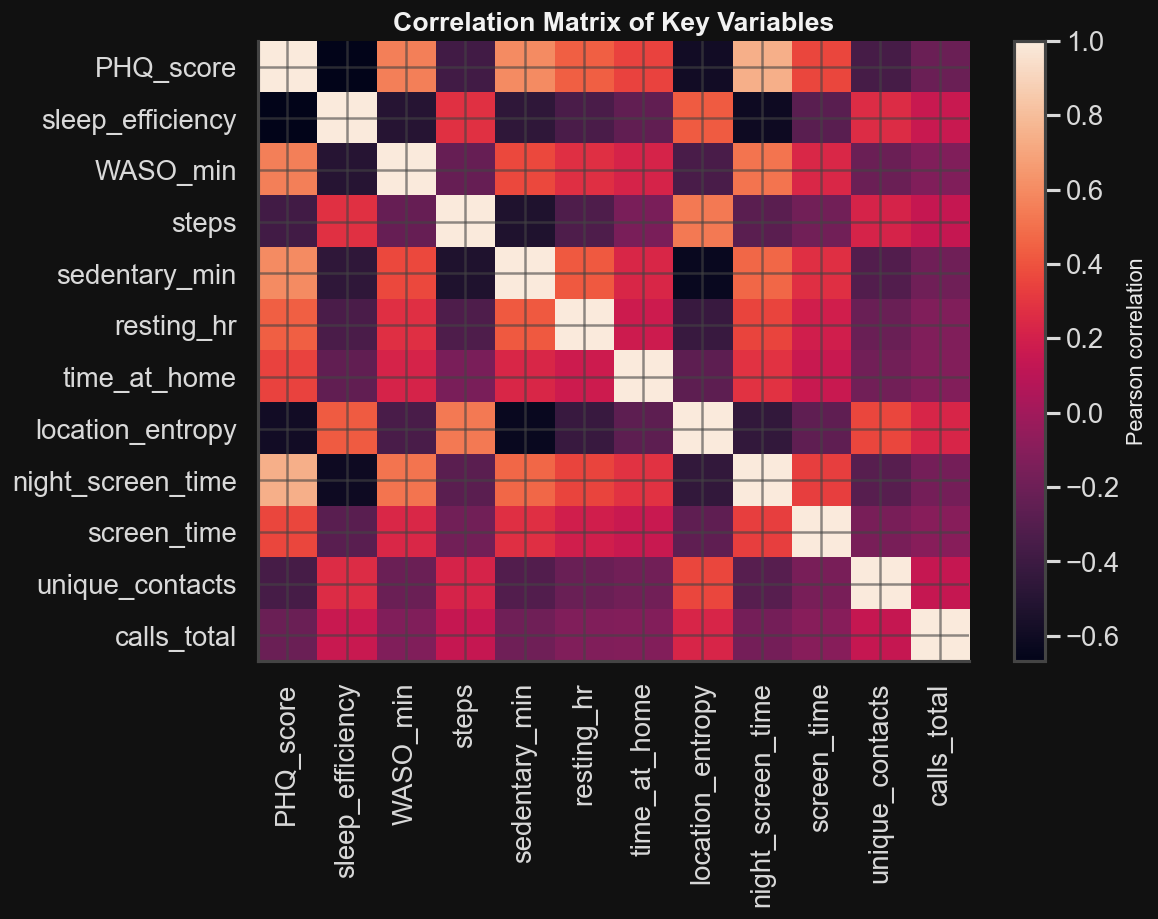

In [42]:
# ============================================================
# CELL 4: CORRELATION ANALYSIS
# ============================================================
# Purpose:
# To examine whether relationships among variables are consistent
# with expected clinical and behavioral assumptions.
# ============================================================

# Merge daily data with clinical assessments if both have participant_id and week
if {"participant_id", "week"}.issubset(daily_data.columns) and {"participant_id", "week"}.issubset(clinical_assessments.columns):
    analysis_df = daily_data.merge(
        clinical_assessments,
        on=["participant_id", "week"],
        how="left"
    )
else:
    raise ValueError("Both daily_data and clinical_assessments must contain 'participant_id' and 'week' columns.")

# Select key variables for correlation
correlation_vars = [
    "PHQ_score",
    "sleep_efficiency",
    "WASO_min",
    "steps",
    "sedentary_min",
    "avg_hrv_or_night_hrv",
    "resting_hr",
    "time_at_home",
    "location_entropy",
    "night_screen_time",
    "screen_time",
    "unique_contacts",
    "calls_total",
    "call_duration"
]

correlation_vars = [v for v in correlation_vars if v in analysis_df.columns]

# Keep numeric variables only
numeric_corr_df = analysis_df[correlation_vars].select_dtypes(include=[np.number])

# Correlation matrix
corr_matrix = numeric_corr_df.corr(method="pearson")

display(corr_matrix)

# Save correlation matrix
corr_matrix.to_csv("outputs/correlation_matrix.csv")

# Plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix of Key Variables")
plt.tight_layout()
plt.savefig("outputs/plots/correlation_heatmap.png", dpi=300)
plt.show()

In [43]:
# ============================================================
# CELL 5: SELECTED CLINICALLY MEANINGFUL CORRELATIONS
# ============================================================
# Purpose:
# To inspect expected relationships, such as whether higher
# PHQ-9 scores relate to lower activity, poorer sleep, or more
# sedentary behavior.
# ============================================================

expected_relationships = [
    ("PHQ_score", "steps"),
    ("PHQ_score", "sedentary_min"),
    ("PHQ_score", "sleep_efficiency"),
    ("PHQ_score", "WASO_min"),
    ("PHQ_score", "time_at_home"),
    ("PHQ_score", "location_entropy"),
    ("PHQ_score", "night_screen_time"),
    ("PHQ_score", "screen_time"),
    ("PHQ_score", "avg_hrv_or_night_hrv"),
    ("PHQ_score", "unique_contacts"),
    ("sleep_efficiency", "steps"),
    ("sleep_efficiency", "sedentary_min"),
    ("steps", "sedentary_min"),
    ("time_at_home", "location_entropy")
]

relationship_results = []

for var1, var2 in expected_relationships:
    if var1 in analysis_df.columns and var2 in analysis_df.columns:
        if pd.api.types.is_numeric_dtype(analysis_df[var1]) and pd.api.types.is_numeric_dtype(analysis_df[var2]):
            corr_value = analysis_df[[var1, var2]].corr().iloc[0, 1]
            relationship_results.append({
                "Variable 1": var1,
                "Variable 2": var2,
                "Pearson correlation": corr_value
            })

relationship_df = pd.DataFrame(relationship_results)

display(relationship_df)

relationship_df.to_csv("outputs/selected_clinical_correlations.csv", index=False)

,Variable 1,Variable 2,Pearson correlation
0,PHQ_score,steps,-0.377410
1,PHQ_score,sedentary_min,0.600615
2,PHQ_score,sleep_efficiency,-0.668681
3,PHQ_score,WASO_min,0.556066
4,PHQ_score,time_at_home,0.341966
5,PHQ_score,location_entropy,-0.587755
6,PHQ_score,night_screen_time,0.744219
7,PHQ_score,screen_time,0.360875
8,PHQ_score,unique_contacts,-0.357325
9,sleep_efficiency,steps,0.277401


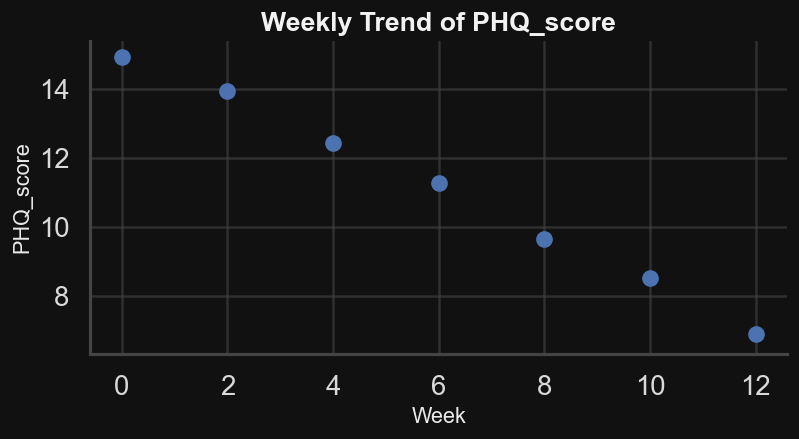

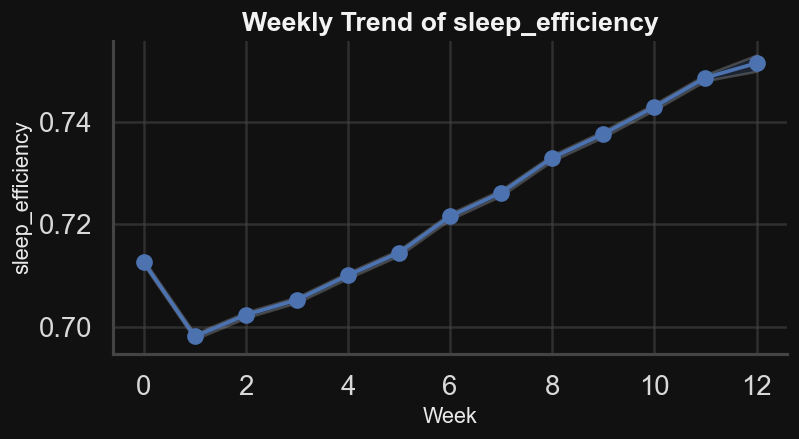

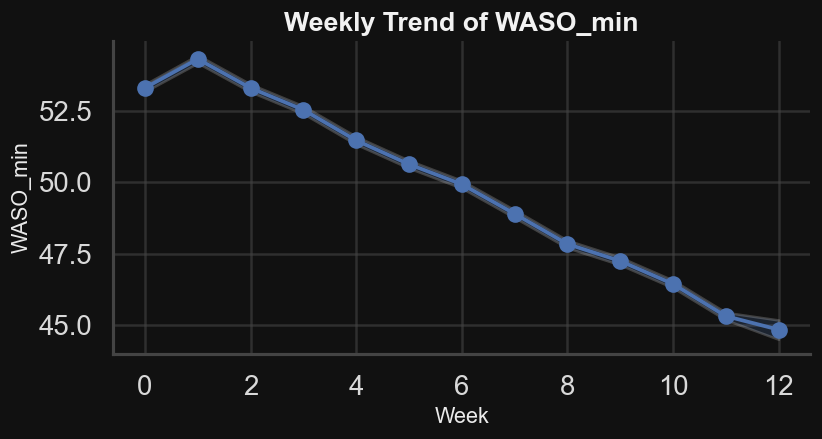

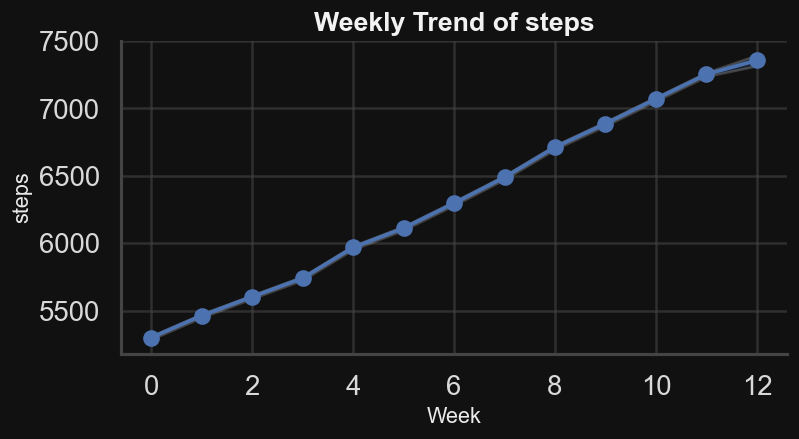

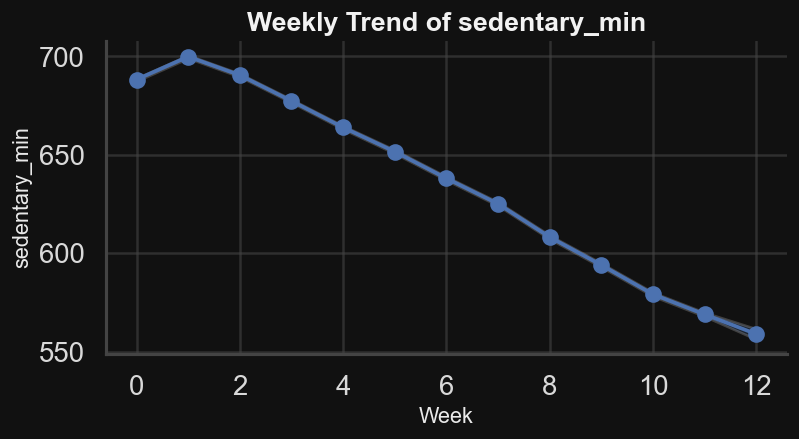

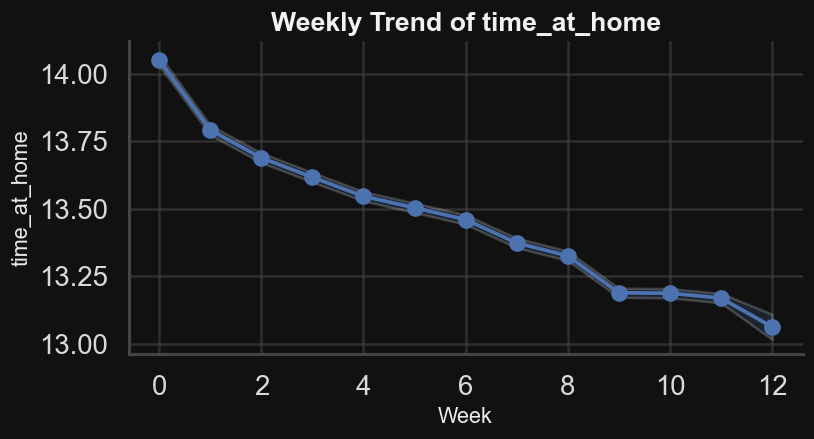

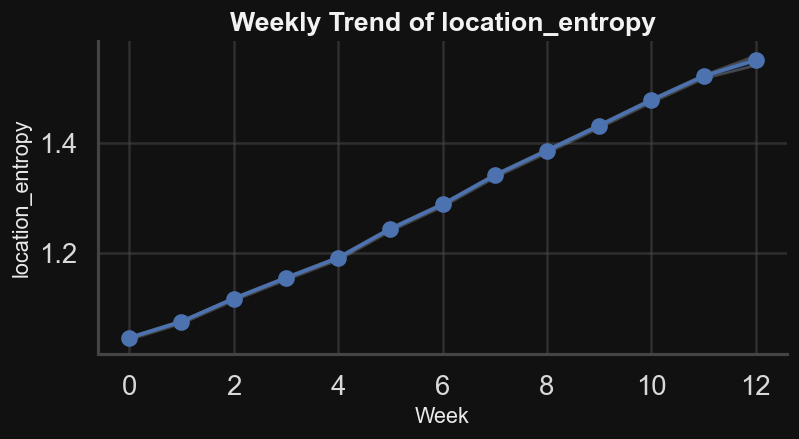

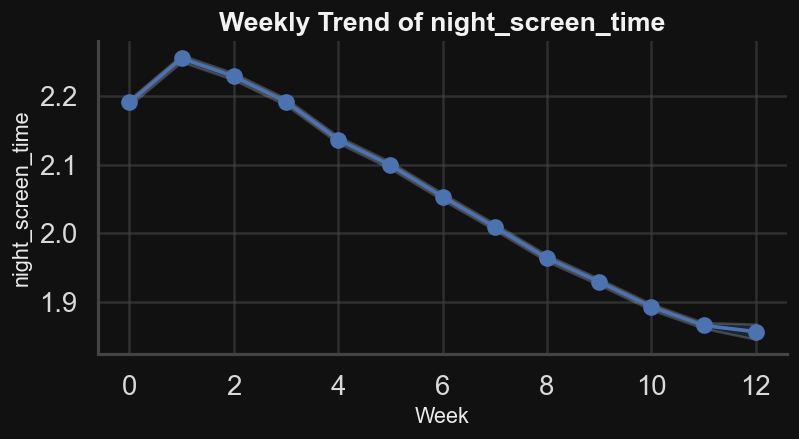

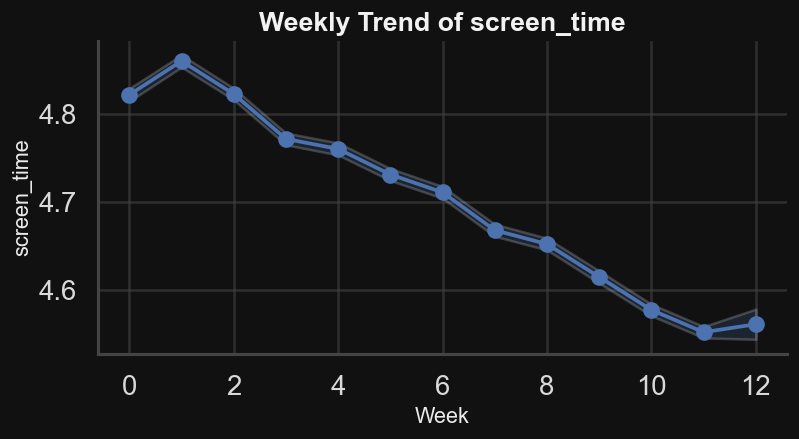

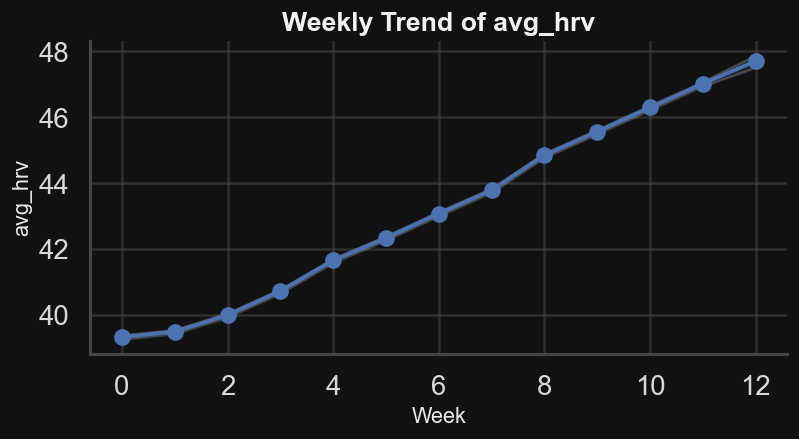

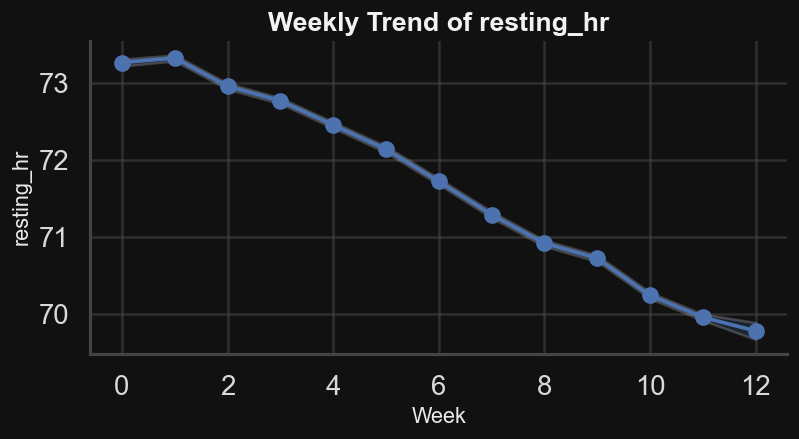

Longitudinal trajectory plots completed.


In [55]:
# ============================================================
# CELL 6: LONGITUDINAL TRAJECTORY PLOTS
# ============================================================
# Purpose:
# To assess symptom progression and behavioral change over time.
# ============================================================

trajectory_vars = [
    "PHQ_score",
    "sleep_efficiency",
    "WASO_min",
    "steps",
    "sedentary_min",
    "time_at_home",
    "location_entropy",
    "night_screen_time",
    "screen_time",
    "avg_hrv",
    "resting_hr"
]

trajectory_vars = [v for v in trajectory_vars if v in analysis_df.columns]

if "week" not in analysis_df.columns:
    raise ValueError("The merged dataset must contain a 'week' column.")

for var in trajectory_vars:
    if pd.api.types.is_numeric_dtype(analysis_df[var]):
        weekly_summary = (
            analysis_df.groupby("week")[var]
            .agg(["mean", "std", "count"])
            .reset_index()
        )

        weekly_summary["standard_error"] = weekly_summary["std"] / np.sqrt(weekly_summary["count"])

        plt.figure(figsize=(7, 4))
        plt.plot(weekly_summary["week"], weekly_summary["mean"], marker="o")
        plt.fill_between(
            weekly_summary["week"],
            weekly_summary["mean"] - weekly_summary["standard_error"],
            weekly_summary["mean"] + weekly_summary["standard_error"],
            alpha=0.2
        )
        plt.title(f"Weekly Trend of {var}")
        plt.xlabel("Week")
        plt.ylabel(var)
        plt.tight_layout()
        plt.savefig(f"outputs/plots/weekly_trend_{var}.png", dpi=300)
        plt.show()

print("Longitudinal trajectory plots completed.")

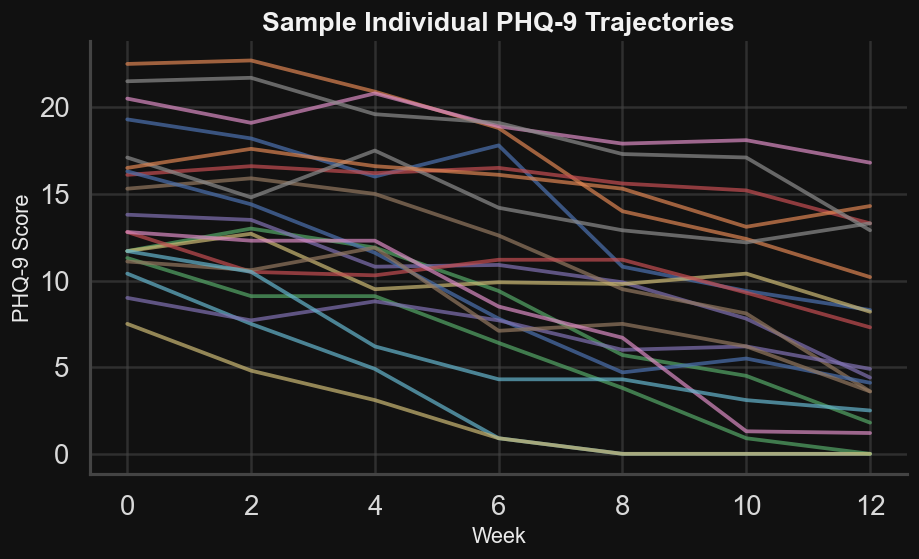

In [45]:
# ============================================================
# CELL 7: SAMPLE INDIVIDUAL PHQ-9 TRAJECTORIES
# ============================================================
# Purpose:
# To visually inspect individual symptom progression patterns.
# ============================================================

if {"participant_id", "week", "PHQ_score"}.issubset(clinical_assessments.columns):
    unique_ids = clinical_assessments["participant_id"].dropna().unique()

    sample_size = min(20, len(unique_ids))
    sample_ids = np.random.default_rng(42).choice(unique_ids, size=sample_size, replace=False)

    sample_df = clinical_assessments[clinical_assessments["participant_id"].isin(sample_ids)]

    plt.figure(figsize=(8, 5))

    for pid, group in sample_df.groupby("participant_id"):
        group = group.sort_values("week")
        plt.plot(group["week"], group["PHQ_score"], alpha=0.7)

    plt.title("Sample Individual PHQ-9 Trajectories")
    plt.xlabel("Week")
    plt.ylabel("PHQ-9 Score")
    plt.tight_layout()
    plt.savefig("outputs/plots/sample_individual_phq9_trajectories.png", dpi=300)
    plt.show()

else:
    print("Required columns not found in clinical_assessments.")

In [46]:
# ============================================================
# CELL 8: RESPONDER GROUP COMPARISONS
# ============================================================
# Purpose:
# To evaluate whether early responders, late responders,
# partial responders, non-responders, and unstable responders
# show distinct profiles.
# ============================================================

# Find responder group column
group_col = None

if "trajectory_group" in final_outcomes.columns:
    group_col = "trajectory_group"
elif "final_response_status" in final_outcomes.columns:
    group_col = "final_response_status"
elif "response_status" in clinical_assessments.columns:
    group_col = "response_status"

if group_col is None:
    raise ValueError("No responder group column found. Expected 'trajectory_group', 'final_response_status', or 'response_status'.")

# If group is in final_outcomes, merge into clinical assessments
if group_col in final_outcomes.columns:
    responder_df = clinical_assessments.merge(
        final_outcomes[["participant_id", group_col]],
        on="participant_id",
        how="left"
    )
else:
    responder_df = clinical_assessments.copy()

# Count participants by responder group
group_counts = (
    responder_df[["participant_id", group_col]]
    .drop_duplicates()
    .groupby(group_col)
    .size()
    .reset_index(name="number_of_participants")
)

group_counts["percentage"] = (
    group_counts["number_of_participants"] /
    group_counts["number_of_participants"].sum() * 100
)

display(group_counts)

group_counts.to_csv("outputs/responder_group_counts.csv", index=False)

,final_response_status,number_of_participants,percentage
0,non_responder,126,12.6
1,partial_responder,289,28.9
2,responder,585,58.5


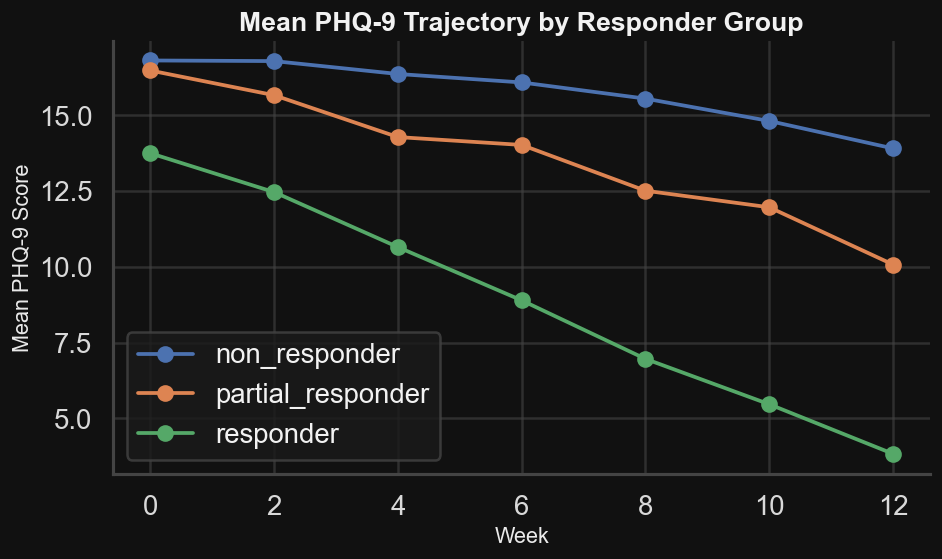

,final_response_status,week,mean,std,count,standard_error
0,non_responder,0,16.812698,4.235129,126,0.377295
1,non_responder,2,16.792063,4.201078,126,0.374262
2,non_responder,4,16.366667,4.124250,126,0.367417
3,non_responder,6,16.087302,4.210558,126,0.375106
4,non_responder,8,15.553175,4.229472,126,0.376791
5,non_responder,10,14.815873,4.017092,126,0.357871
6,non_responder,12,13.909524,3.788750,126,0.337529
7,partial_responder,0,16.481661,3.827030,289,0.225119
8,partial_responder,2,15.666090,3.751781,289,0.220693
9,partial_responder,4,14.284083,3.691011,289,0.217118


In [47]:
# ============================================================
# CELL 9: PHQ-9 TRAJECTORIES BY RESPONDER GROUP
# ============================================================
# Purpose:
# To assess whether each responder group shows a distinct
# clinical trajectory over time.
# ============================================================

if {"week", "PHQ_score", group_col}.issubset(responder_df.columns):

    group_trajectory = (
        responder_df.groupby([group_col, "week"])["PHQ_score"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    group_trajectory["standard_error"] = group_trajectory["std"] / np.sqrt(group_trajectory["count"])

    plt.figure(figsize=(8, 5))

    for group_name, group_data in group_trajectory.groupby(group_col):
        plt.plot(group_data["week"], group_data["mean"], marker="o", label=str(group_name))

    plt.title("Mean PHQ-9 Trajectory by Responder Group")
    plt.xlabel("Week")
    plt.ylabel("Mean PHQ-9 Score")
    plt.legend()
    plt.tight_layout()
    plt.savefig("outputs/plots/phq9_trajectory_by_responder_group.png", dpi=300)
    plt.show()

    display(group_trajectory)

    group_trajectory.to_csv("outputs/phq9_trajectory_by_responder_group.csv", index=False)

else:
    print("Required columns not found.")

In [48]:
# ============================================================
# CELL 10: BEHAVIORAL PROFILE BY RESPONDER GROUP
# ============================================================
# Purpose:
# To evaluate whether responder groups show different
# behavioral and physiological profiles.
# ============================================================

# Merge daily data with responder group
if group_col in final_outcomes.columns:
    behavior_group_df = daily_data.merge(
        final_outcomes[["participant_id", group_col]],
        on="participant_id",
        how="left"
    )
else:
    behavior_group_df = daily_data.merge(
        clinical_assessments[["participant_id", group_col]].drop_duplicates(),
        on="participant_id",
        how="left"
    )

behavior_vars = [
    "sleep_efficiency",
    "WASO_min",
    "steps",
    "sedentary_min",
    "time_at_home",
    "location_entropy",
    "night_screen_time",
    "screen_time",
    "unique_contacts",
    "avg_hrv_or_night_hrv",
    "resting_hr"
]

behavior_vars = [v for v in behavior_vars if v in behavior_group_df.columns]

group_behavior_summary = (
    behavior_group_df.groupby(group_col)[behavior_vars]
    .agg(["mean", "std", "median"])
)

display(group_behavior_summary)

group_behavior_summary.to_csv("outputs/behavioral_profile_by_responder_group.csv")

sleep_efficiency                    WASO_min             \
                                  mean       std median       mean        std   
final_response_status                                                           
non_responder                 0.690032  0.047284  0.691  56.506406  12.229615   
partial_responder             0.704402  0.045804  0.705  52.790649  11.381241   
responder                     0.736509  0.049170  0.737  47.284322  10.774952   

                                    steps                      sedentary_min  \
                      median         mean          std  median          mean   
final_response_status                                                          
non_responder           56.1  5654.356676  1161.400780  5647.0    693.143511   
partial_responder       52.5  6058.804804  1223.304422  6052.0    663.166294   
responder               47.1  6480.775204  1385.122729  6454.0    616.226807   

                                        time_at_home                   \
                             std median         mean       std median   
final_response_status                                                   
non_responder          72.878973  693.0    13.969777  1.512317  13.98   
partial_responder      75.492883  663.0    13.698777  1.496986  13.69   
responder              90.083741  617.0    13.277305  1.449211  13.26   

                      location_entropy                  night_screen_time  \
                                  mean       std median              mean   
final_response_status                                                       
non_responder                 1.085362  0.245380  1.085          2.371642   
partial_responder             1.208434  0.261038  1.209          2.198901   
responder                     1.350737  0.310420  1.343          1.933760   

                                       screen_time                   \
                            std median        mean       std median   
final_response_status                                                 
non_responder          0.430020   2.36    4.934121  0.589669   4.93   
partial_responder      0.390870   2.18    4.798051  0.569953   4.79   
responder              0.361253   1.90    4.618708  0.549191   4.61   

                      unique_contacts                  resting_hr            \
                                 mean       std median       mean       std   
final_response_status                                                         
non_responder                2.783660  0.847717    3.0  73.398142  3.342325   
partial_responder            2.986648  0.856159    3.0  72.463554  3.269445   
responder                    3.240463  0.869881    3.0  71.110707  3.513652   

                              
                      median  
final_response_status         
non_responder           73.3  
partial_responder       72.5  
responder               71.1

In [49]:
# ============================================================
# CELL 11: MISSINGNESS CHECKS
# ============================================================
# Purpose:
# To assess whether missing data patterns are present but not
# excessive or unrealistic.
# ============================================================

datasets = {
    "participants": participants,
    "daily_data": daily_data,
    "clinical_assessments": clinical_assessments,
    "final_outcomes": final_outcomes,
    "weekly_summary": weekly_summary
}

missingness_tables = {}

for name, dataset in datasets.items():
    missing_summary = pd.DataFrame({
        "missing_count": dataset.isna().sum(),
        "missing_percentage": dataset.isna().mean() * 100
    }).sort_values("missing_percentage", ascending=False)

    missingness_tables[name] = missing_summary

    print(f"\nMissingness summary for {name}:")
    display(missing_summary)

    missing_summary.to_csv(f"outputs/missingness_{name}.csv")


Missingness summary for participants:


,missing_count,missing_percentage
time_to_response_weeks,409,40.9
participant_id,0,0.0
treatment_start_date,0,0.0
sustained_improvement_flag,0,0.0
week12_treatment_review_decision,0,0.0
final_worsening_status,0,0.0
final_remission_status,0,0.0
final_response_status,0,0.0
final_percent_change_from_baseline,0,0.0
final_change_from_baseline,0,0.0



Missingness summary for daily_data:


,missing_count,missing_percentage
therapy_adherence,25755,30.300000
med_adherence,20910,24.600000
WASO_min,1,0.001176
sleep_efficiency,1,0.001176
participant_id,0,0.000000
screen_time,0,0.000000
night_screen_time,0,0.000000
app_sessions_total,0,0.000000
app_sessions_social,0,0.000000
unique_contacts,0,0.000000



Missingness summary for clinical_assessments:


,missing_count,missing_percentage
treatment_review_decision,4000,57.142857
participant_id,0,0.000000
assessment_date,0,0.000000
week,0,0.000000
PHQ_score,0,0.000000
change_from_baseline,0,0.000000
percent_change_from_baseline,0,0.000000
response_status,0,0.000000
remission_status,0,0.000000
worsening_status,0,0.000000



Missingness summary for final_outcomes:


,missing_count,missing_percentage
time_to_response_weeks,409,40.9
participant_id,0,0.0
final_week12_PHQ_score,0,0.0
final_change_from_baseline,0,0.0
final_percent_change_from_baseline,0,0.0
final_response_status,0,0.0
final_remission_status,0,0.0
final_worsening_status,0,0.0
week12_treatment_review_decision,0,0.0
sustained_improvement_flag,0,0.0



Missingness summary for weekly_summary:


,missing_count,missing_percentage
week,0,0.0
mean,0,0.0
std,0,0.0
count,0,0.0
standard_error,0,0.0


In [50]:
# ============================================================
# CELL 12: MISSINGNESS OVER TIME
# ============================================================
# Purpose:
# To assess missingness patterns across the longitudinal
# monitoring period.
# ============================================================

if "week" in daily_data.columns:
    daily_missing_by_week = daily_data.groupby("week").apply(lambda x: x.isna().mean() * 100)

    display(daily_missing_by_week)

    daily_missing_by_week.to_csv("outputs/daily_missingness_by_week.csv")
else:
    print("No 'week' column found in daily_data.")

,participant_id,date,study_day,day_of_week,is_weekend,life_event_flag,ema_anhedonia,ema_energy,ema_stress,sleep_efficiency,WASO_min,avg_hrv,resting_hr,steps,sedentary_min,time_at_home,location_entropy,distance_traveled_km,bedtime_variability_min,wake_variability_min,screen_time,night_screen_time,app_sessions_total,app_sessions_social,unique_contacts,calls_total,call_duration_min,med_adherence,therapy_adherence,overall_adherence,gps_missing_pct,hr_missing_pct,gps_outage_flag,wearable_nonwear_flag,passive_dropout_flag
week,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0


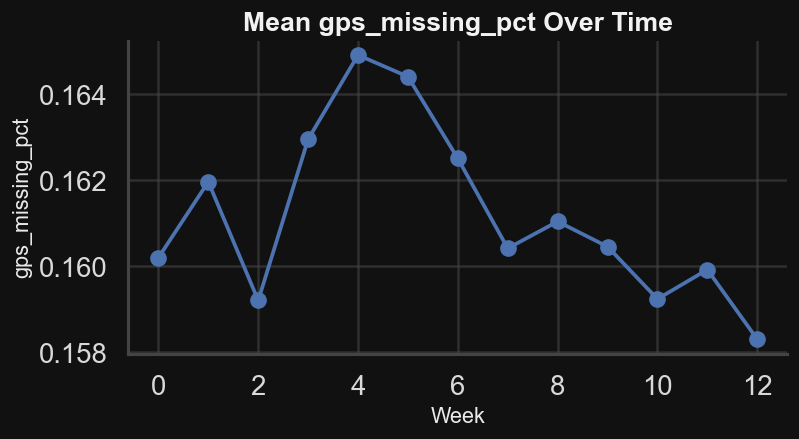

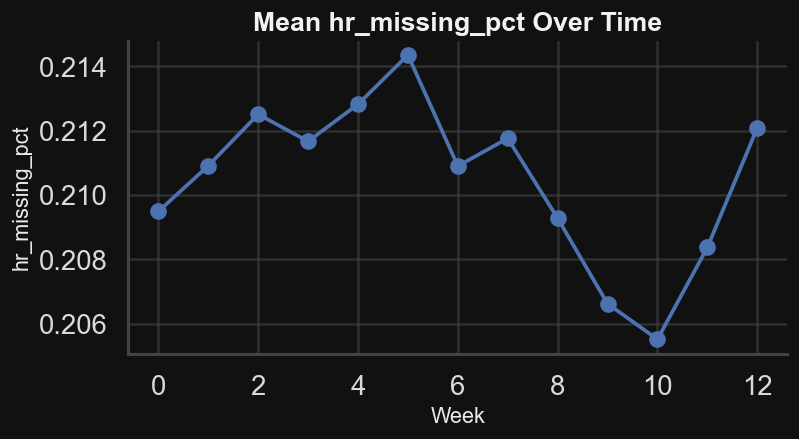

In [51]:
# ============================================================
# CELL 13: SENSOR MISSINGNESS OVER TIME
# ============================================================
# Purpose:
# To inspect GPS and heart-rate missingness trends over time.
# ============================================================

sensor_missing_vars = [
    "gps_missing_pct",
    "hr_missing_pct"
]

sensor_missing_vars = [v for v in sensor_missing_vars if v in daily_data.columns]

if "week" in daily_data.columns and len(sensor_missing_vars) > 0:
    for var in sensor_missing_vars:
        weekly_sensor_missing = daily_data.groupby("week")[var].mean().reset_index()

        plt.figure(figsize=(7, 4))
        plt.plot(weekly_sensor_missing["week"], weekly_sensor_missing[var], marker="o")
        plt.title(f"Mean {var} Over Time")
        plt.xlabel("Week")
        plt.ylabel(var)
        plt.tight_layout()
        plt.savefig(f"outputs/plots/weekly_{var}.png", dpi=300)
        plt.show()
else:
    print("Sensor missingness variables or week column not found.")

In [52]:
# ============================================================
# CELL 14: PLAUSIBILITY ASSESSMENT SUMMARY TABLE
# ============================================================
# Purpose:
# To summarize the validation checks performed on the generated
# rule-based synthetic dataset.
# ============================================================

plausibility_summary = pd.DataFrame({
    "Plausibility dimension": [
        "Distribution realism",
        "Dependency realism",
        "Temporal realism",
        "Clinical realism",
        "Missingness realism"
    ],
    "Assessment performed": [
        "Distribution plots of key behavioral, physiological, and clinical variables",
        "Correlation analysis and selected clinically meaningful relationships",
        "Longitudinal trajectory plots of symptoms and behavioral variables",
        "Responder group comparisons using PHQ-9 trajectories and behavioral profiles",
        "Missingness checks across variables, datasets, and time"
    ],
    "Purpose": [
        "To inspect whether generated variables showed plausible value distributions",
        "To examine whether variable relationships followed expected clinical and behavioral assumptions",
        "To assess whether symptom progression and behavioral change evolved plausibly over time",
        "To evaluate whether responder groups showed distinct and clinically meaningful profiles",
        "To ensure missing data patterns were present but not excessive or unrealistic"
    ]
})

display(plausibility_summary)

plausibility_summary.to_csv("outputs/plausibility_assessment_summary.csv", index=False)

,Plausibility dimension,Assessment performed,Purpose
0,Distribution realism,"Distribution plots of key behavioral, physiolo...",To inspect whether generated variables showed ...
1,Dependency realism,Correlation analysis and selected clinically m...,To examine whether variable relationships foll...
2,Temporal realism,Longitudinal trajectory plots of symptoms and ...,To assess whether symptom progression and beha...
3,Clinical realism,Responder group comparisons using PHQ-9 trajec...,To evaluate whether responder groups showed di...
4,Missingness realism,"Missingness checks across variables, datasets,...",To ensure missing data patterns were present b...


In [56]:
# ============================================================
# CELL A: CREATE MERGED ANALYSIS DATASET
# ============================================================
# Purpose:
# To combine daily_data, participants, clinical_assessments,
# and final_outcomes into one dataset for plausibility analysis.
# ============================================================

analysis_df = daily_data.copy()

# Merge participant-level information
if "participant_id" in analysis_df.columns and "participant_id" in participants.columns:
    analysis_df = analysis_df.merge(
        participants,
        on="participant_id",
        how="left",
        suffixes=("", "_participant")
    )

# Merge clinical assessments using participant_id and week
if {"participant_id", "week"}.issubset(analysis_df.columns) and {"participant_id", "week"}.issubset(clinical_assessments.columns):
    analysis_df = analysis_df.merge(
        clinical_assessments,
        on=["participant_id", "week"],
        how="left",
        suffixes=("", "_clinical")
    )

# Merge final outcomes using participant_id
if "participant_id" in analysis_df.columns and "participant_id" in final_outcomes.columns:
    analysis_df = analysis_df.merge(
        final_outcomes,
        on="participant_id",
        how="left",
        suffixes=("", "_final")
    )

print("Merged analysis dataset created.")
print("Shape:", analysis_df.shape)

display(analysis_df.head())

Merged analysis dataset created.
Shape: (85000, 78)


,participant_id,date,study_day,week,day_of_week,is_weekend,life_event_flag,ema_anhedonia,ema_energy,ema_stress,sleep_efficiency,WASO_min,avg_hrv,resting_hr,steps,sedentary_min,time_at_home,location_entropy,distance_traveled_km,bedtime_variability_min,wake_variability_min,screen_time,night_screen_time,app_sessions_total,app_sessions_social,unique_contacts,calls_total,call_duration_min,med_adherence,therapy_adherence,overall_adherence,gps_missing_pct,hr_missing_pct,gps_outage_flag,wearable_nonwear_flag,passive_dropout_flag,age,sex,ethnicity,site_region,time_zone,device_phone_os,wearable_type,baseline_phq_score,initial_severity_group,adherence_risk_profile,treatment_type,treatment_start_date,final_week12_PHQ_score,final_change_from_baseline,final_percent_change_from_baseline,final_response_status,final_remission_status,final_worsening_status,week12_treatment_review_decision,time_to_response_weeks,sustained_improvement_flag,trajectory_group_derived,assessment_date,PHQ_score,change_from_baseline,percent_change_from_baseline,response_status,remission_status,worsening_status,treatment_review_decision,trajectory_group,life_event_in_prior_7d,final_week12_PHQ_score_final,final_change_from_baseline_final,final_percent_change_from_baseline_final,final_response_status_final,final_remission_status_final,final_worsening_status_final,week12_treatment_review_decision_final,time_to_response_weeks_final,sustained_improvement_flag_final,trajectory_group_derived_final
0,0,01/01/2024,0,0,0,0,0,2,2,2,0.766,29.9,25.7,69.4,6544,709,12.43,0.864,7.44,55.4,55.7,5.01,2.08,46,15,3,2,12.2,0.687,0.659,0.673,0.246,0.507,0,0,0,42,female,African,Nairobi,Africa/Nairobi,iOS,Samsung Watch,16,moderately_severe,high,combined,01/01/2024,13.8,-2.2,13.75,non_responder,no,no,adjust,NaN,0,non_responder,01/01/2024,16.7,0.7,-4.37,non_responder,no,no,NaN,non_responder,0.0,13.8,-2.2,13.75,non_responder,no,no,adjust,NaN,0,non_responder
1,0,02/01/2024,1,0,1,0,0,3,2,3,0.740,38.5,28.8,71.1,5945,726,13.82,1.172,7.57,63.8,66.2,5.09,2.30,50,16,2,2,14.3,0.676,0.711,0.694,0.110,0.377,0,0,0,42,female,African,Nairobi,Africa/Nairobi,iOS,Samsung Watch,16,moderately_severe,high,combined,01/01/2024,13.8,-2.2,13.75,non_responder,no,no,adjust,NaN,0,non_responder,01/01/2024,16.7,0.7,-4.37,non_responder,no,no,NaN,non_responder,0.0,13.8,-2.2,13.75,non_responder,no,no,adjust,NaN,0,non_responder
2,0,03/01/2024,2,0,2,0,0,2,3,2,0.737,46.9,28.0,70.4,2945,657,15.04,1.095,5.41,59.9,66.0,5.88,2.33,51,13,3,3,13.5,0.721,0.661,0.691,0.238,0.337,0,0,0,42,female,African,Nairobi,Africa/Nairobi,iOS,Samsung Watch,16,moderately_severe,high,combined,01/01/2024,13.8,-2.2,13.75,non_responder,no,no,adjust,NaN,0,non_responder,01/01/2024,16.7,0.7,-4.37,non_responder,no,no,NaN,non_responder,0.0,13.8,-2.2,13.75,non_responder,no,no,adjust,NaN,0,non_responder
3,0,04/01/2024,3,0,3,0,0,3,3,3,0.702,42.7,33.7,70.4,4091,697,13.42,1.167,6.15,62.8,64.6,5.72,2.07,46,13,3,3,13.7,0.654,0.701,0.677,0.353,0.337,0,0,0,42,female,African,Nairobi,Africa/Nairobi,iOS,Samsung Watch,16,moderately_severe,high,combined,01/01/2024,13.8,-2.2,13.75,non_responder,no,no,adjust,NaN,0,non_responder,01/01/2024,16.7,0.7,-4.37,non_responder,no,no,NaN,non_responder,0.0,13.8,-2.2,13.75,non_responder,no,no,adjust,NaN,0,non_responder
4,0,05/01/2024,4,0,4,0,0,2,2,2,0.701,47.7,37.1,71.0,4836,733,12.86,1.092,6.65,74.8,63.6,5.68,2.19,51,8,3,3,11.8,0.565,0.540,0.553,0.260,0.325,0,0,0,42,female,African,Nairobi,Africa/Nairobi,iOS,Samsung Watch,16,moderately_severe,high,combined,01/01/2024,13.8,-2.2,13.75,non_responder,no,no,adjust,NaN,0,non_responder,01/01/2024,16.7,0.7,-4.37,non_responder,no,no,NaN,non_responder,0.0,13.8,-2.2,13.75,non_responder,no,no,adjust,NaN,0,non_responder


In [57]:
# ============================================================
# CELL B: DESCRIPTIVE STATISTICS FOR ALL DATASETS
# ============================================================
# Purpose:
# To summarize ranges, means, standard deviations, medians,
# IQR, and missingness for numeric variables across all datasets.
# ============================================================

datasets = {
    "participants": participants,
    "daily_data": daily_data,
    "clinical_assessments": clinical_assessments,
    "final_outcomes": final_outcomes,
    "weekly_summary": weekly_summary
}

all_desc = []

for dataset_name, dataset in datasets.items():
    numeric_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()

    if len(numeric_cols) > 0:
        desc = dataset[numeric_cols].describe().T
        desc["dataset"] = dataset_name
        desc["variable"] = desc.index
        desc["median"] = dataset[numeric_cols].median()
        desc["IQR"] = dataset[numeric_cols].quantile(0.75) - dataset[numeric_cols].quantile(0.25)
        desc["missing_count"] = dataset[numeric_cols].isna().sum()
        desc["missing_pct"] = dataset[numeric_cols].isna().mean() * 100

        all_desc.append(desc.reset_index(drop=True))

descriptive_statistics = pd.concat(all_desc, ignore_index=True)

cols = ["dataset", "variable"] + [c for c in descriptive_statistics.columns if c not in ["dataset", "variable"]]
descriptive_statistics = descriptive_statistics[cols]

display(descriptive_statistics)

descriptive_statistics.to_csv("outputs/descriptive_statistics_all_datasets.csv", index=False)

,dataset,variable,count,mean,std,min,25%,50%,75%,max,median,IQR,missing_count,missing_pct
0,participants,participant_id,1000.0,499.500000,288.819436,0.000000,249.750000,499.500000,749.250000,999.000000,499.500000,499.500000,0,0.000000
1,participants,age,1000.0,42.201000,14.042571,18.000000,30.000000,42.000000,55.000000,65.000000,42.000000,25.000000,0,0.000000
2,participants,baseline_phq_score,1000.0,14.849000,3.829734,8.000000,12.000000,15.000000,17.000000,27.000000,15.000000,5.000000,0,0.000000
3,participants,final_week12_PHQ_score,1000.0,6.903800,4.782650,0.000000,3.200000,6.500000,10.200000,24.600000,6.500000,7.000000,0,0.000000
4,participants,final_change_from_baseline,1000.0,-7.945200,3.364943,-14.800000,-10.800000,-8.000000,-5.600000,0.500000,-8.000000,5.200000,0,0.000000
5,participants,final_percent_change_from_baseline,1000.0,56.525820,26.180729,-3.000000,36.880000,56.415000,76.430000,100.000000,56.415000,39.550000,0,0.000000
6,participants,time_to_response_weeks,591.0,8.720812,2.580545,2.000000,6.000000,8.000000,10.000000,12.000000,8.000000,4.000000,409,40.900000
7,participants,sustained_improvement_flag,1000.0,0.556000,0.497103,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0,0.000000
8,daily_data,participant_id,85000.0,499.500000,288.676688,0.000000,249.750000,499.500000,749.250000,999.000000,499.500000,499.500000,0,0.000000
9,daily_data,study_day,85000.0,42.000000,24.535833,0.000000,21.000000,42.000000,63.000000,84.000000,42.000000,42.000000,0,0.000000


In [58]:
# ============================================================
# CELL C: EXPECTED RANGE CHECKS
# ============================================================
# Purpose:
# To check whether important clinical, behavioral, physiological,
# and digital variables fall within plausible expected ranges.
# ============================================================

expected_ranges = {
    "PHQ_score": (0, 27),
    "baseline_phq_score": (0, 27),
    "change_from_baseline": (-27, 27),
    "percent_change_from_baseline": (-200, 100),

    "sleep_efficiency": (0, 100),
    "WASO_min": (0, 300),

    "steps": (0, 30000),
    "sedentary_min": (0, 1440),
    "active_min": (0, 1440),

    "avg_hrv": (0, 200),
    "night_hrv": (0, 200),
    "avg_hrv_or_night_hrv": (0, 200),
    "resting_hr": (35, 140),

    "time_at_home": (0, 1440),
    "location_entropy": (0, 5),
    "distance_traveled": (0, 300),

    "night_screen_time": (0, 600),
    "screen_time": (0, 1440),
    "unique_contacts": (0, 200),
    "calls_total": (0, 200),
    "call_duration": (0, 2000),

    "gps_missing_pct": (0, 100),
    "hr_missing_pct": (0, 100)
}

range_rows = []

for dataset_name, dataset in datasets.items():
    for var, (lower, upper) in expected_ranges.items():
        if var in dataset.columns and pd.api.types.is_numeric_dtype(dataset[var]):
            values = dataset[var].dropna()

            if len(values) > 0:
                below = (values < lower).sum()
                above = (values > upper).sum()
                total = len(values)

                range_rows.append({
                    "dataset": dataset_name,
                    "variable": var,
                    "expected_min": lower,
                    "expected_max": upper,
                    "observed_min": values.min(),
                    "observed_max": values.max(),
                    "below_expected": below,
                    "above_expected": above,
                    "total_non_missing": total,
                    "out_of_range_pct": ((below + above) / total) * 100
                })

range_check = pd.DataFrame(range_rows)

display(range_check)

range_check.to_csv("outputs/expected_range_checks.csv", index=False)

,dataset,variable,expected_min,expected_max,observed_min,observed_max,below_expected,above_expected,total_non_missing,out_of_range_pct
0,participants,baseline_phq_score,0,27,8.000,27.000,0,0,1000,0.0
1,daily_data,sleep_efficiency,0,100,0.496,0.906,0,0,84999,0.0
2,daily_data,WASO_min,0,300,5.000,113.600,0,0,84999,0.0
3,daily_data,steps,0,30000,800.000,11825.000,0,0,85000,0.0
4,daily_data,sedentary_min,0,1440,295.000,1016.000,0,0,85000,0.0
5,daily_data,avg_hrv,0,200,18.600,68.200,0,0,85000,0.0
6,daily_data,resting_hr,35,140,57.100,90.100,0,0,85000,0.0
7,daily_data,time_at_home,0,1440,7.170,20.940,0,0,85000,0.0
8,daily_data,location_entropy,0,5,0.076,2.498,0,0,85000,0.0
9,daily_data,night_screen_time,0,600,0.870,3.830,0,0,85000,0.0


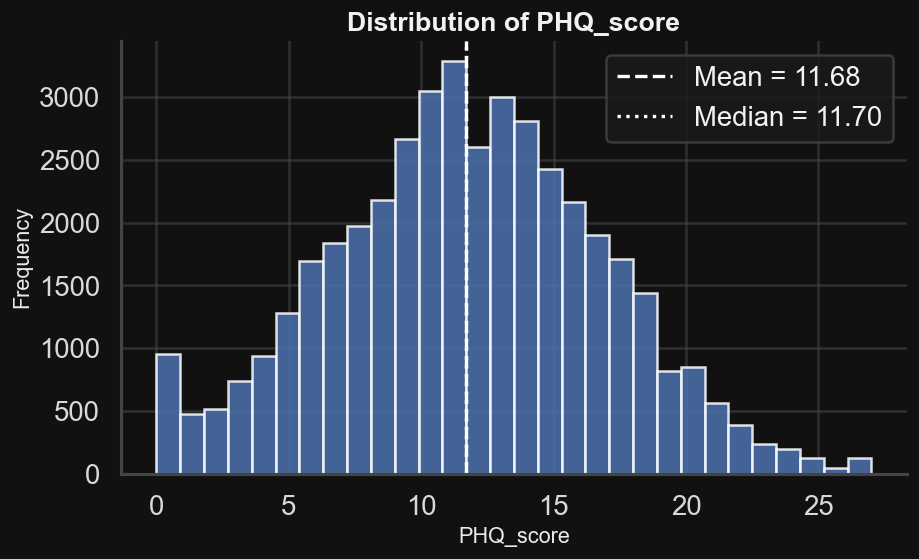

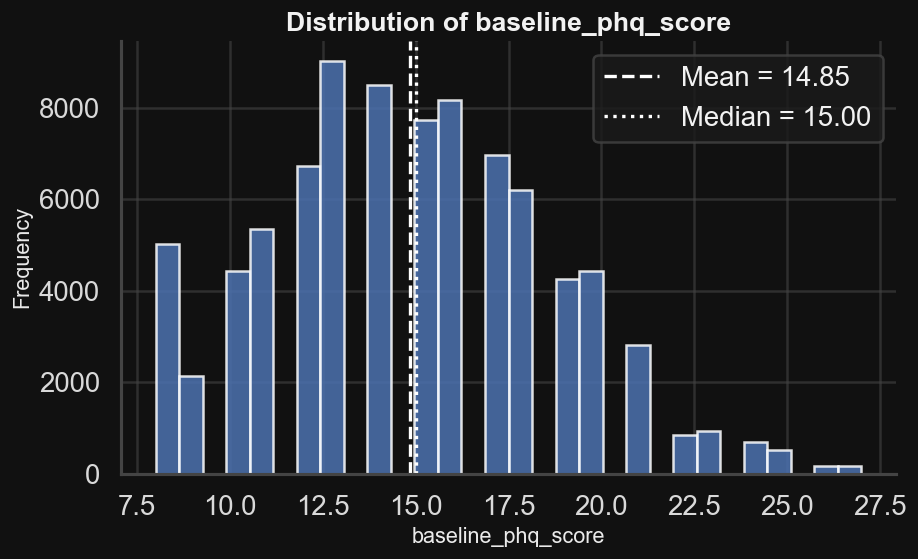

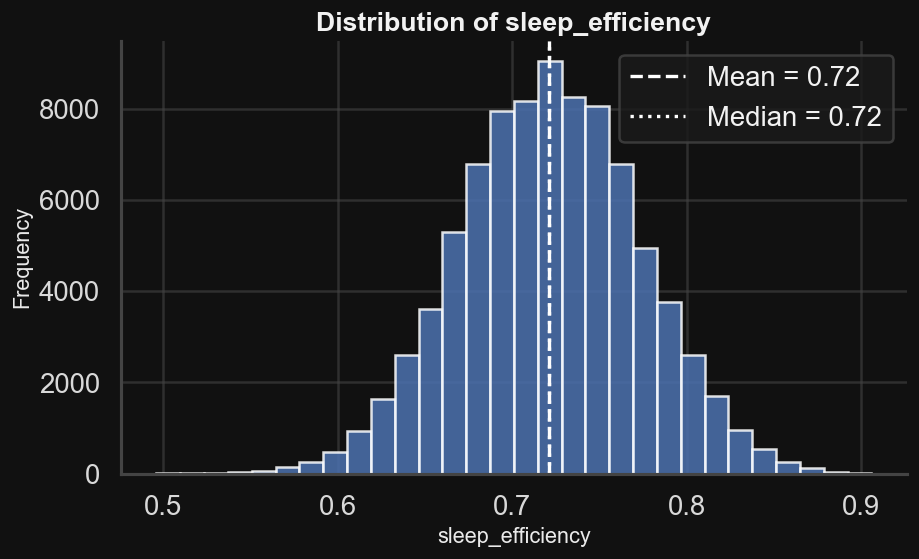

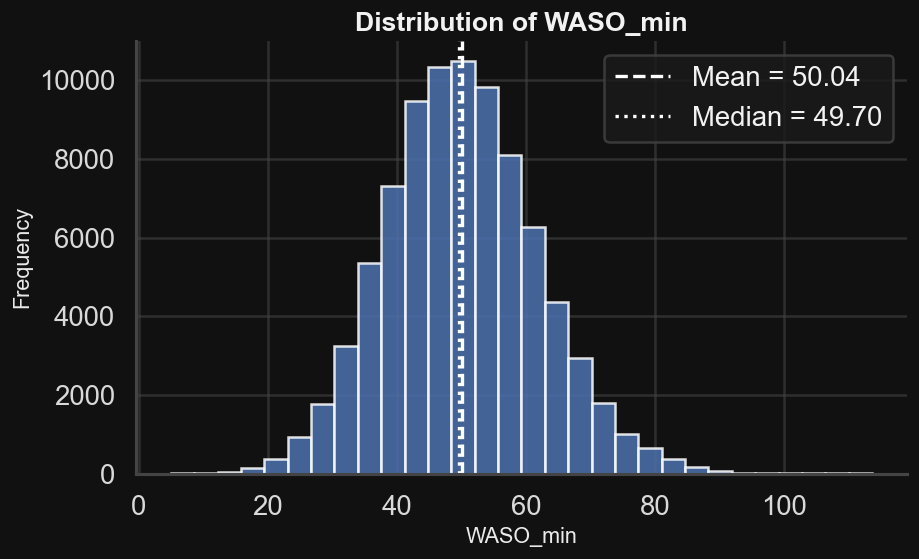

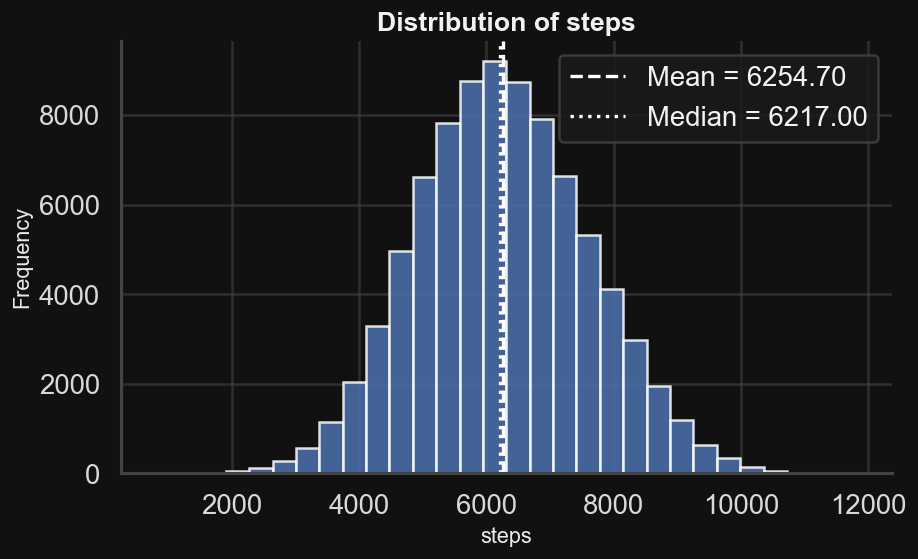

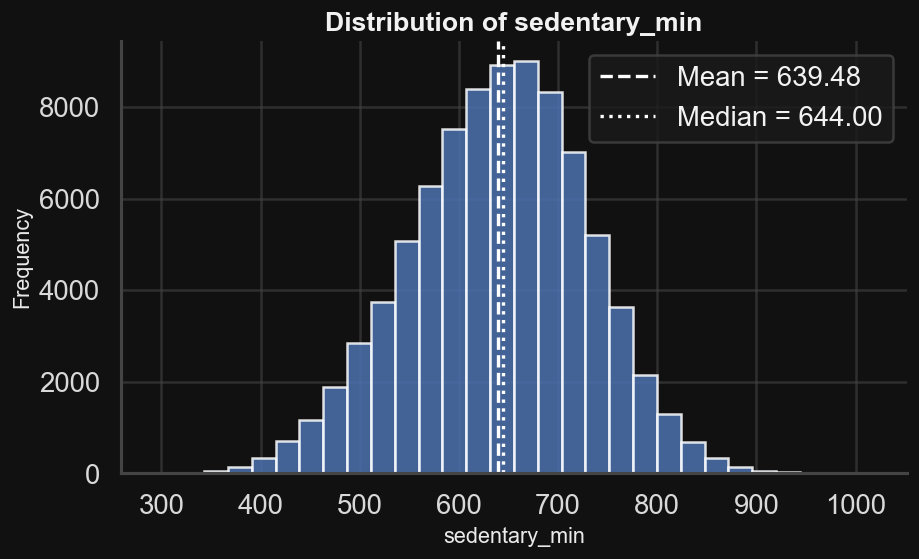

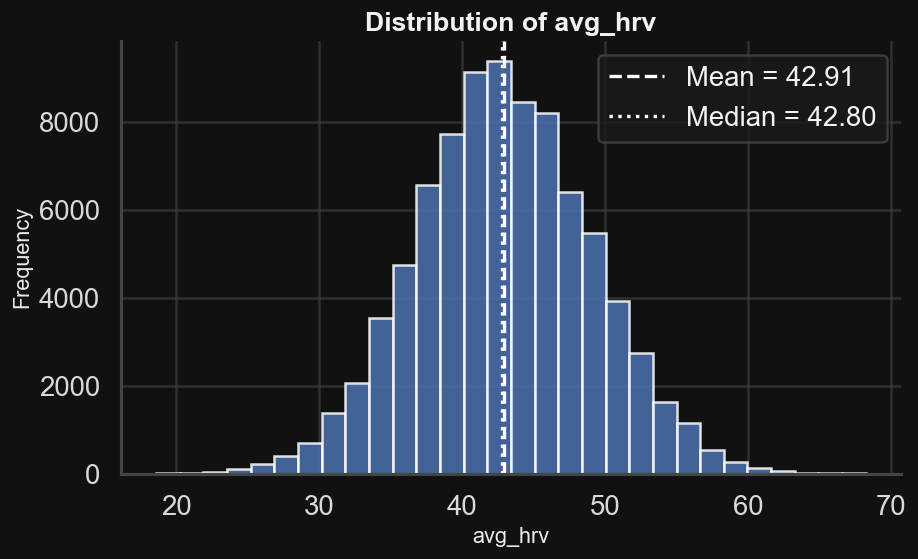

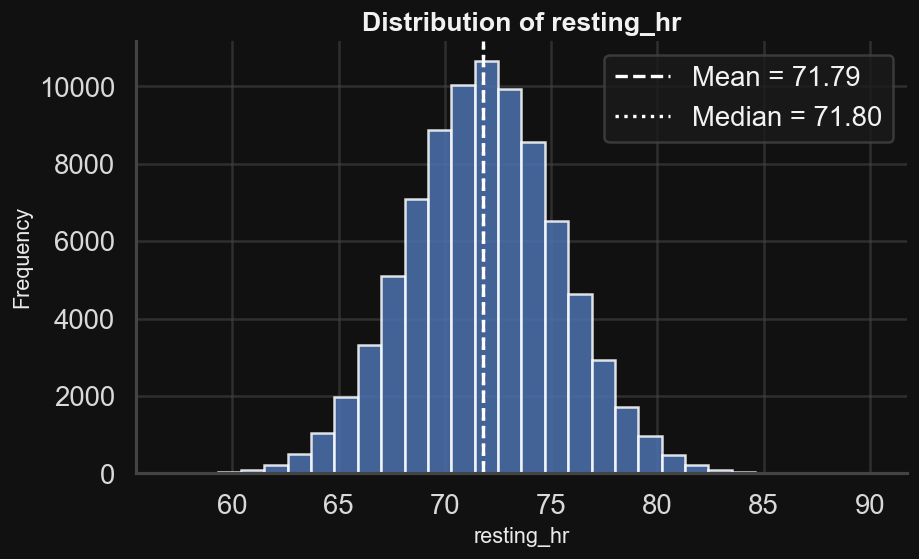

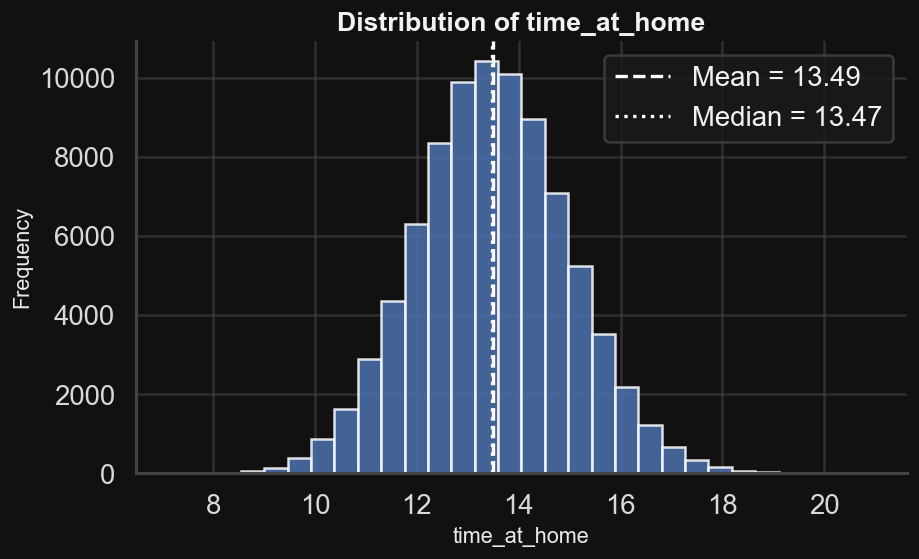

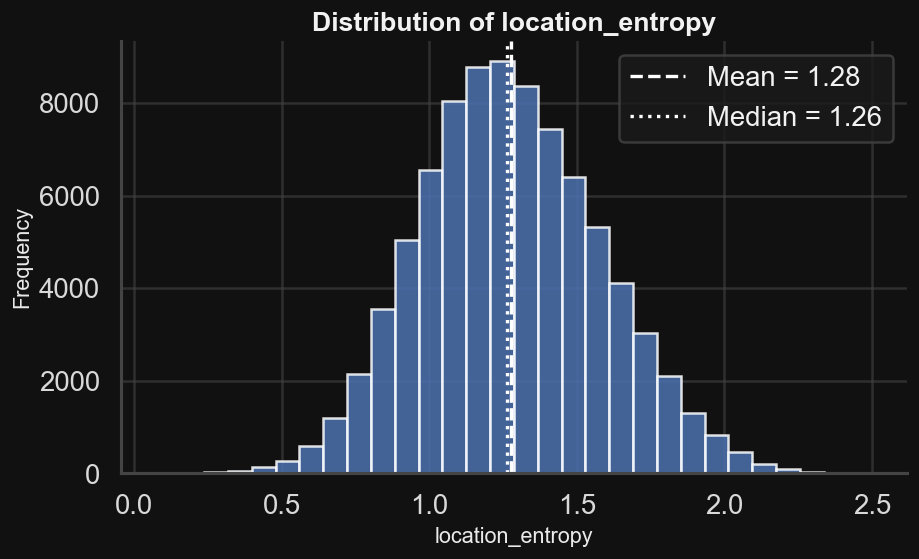

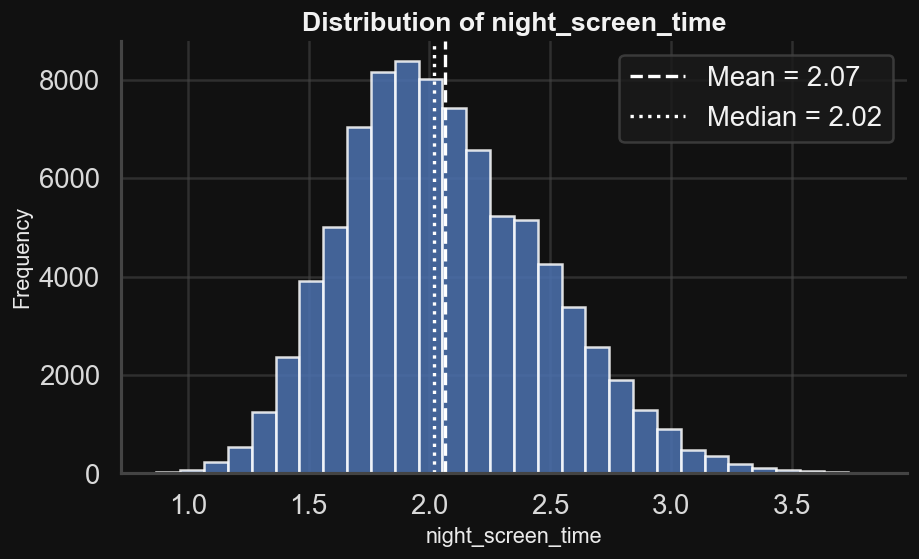

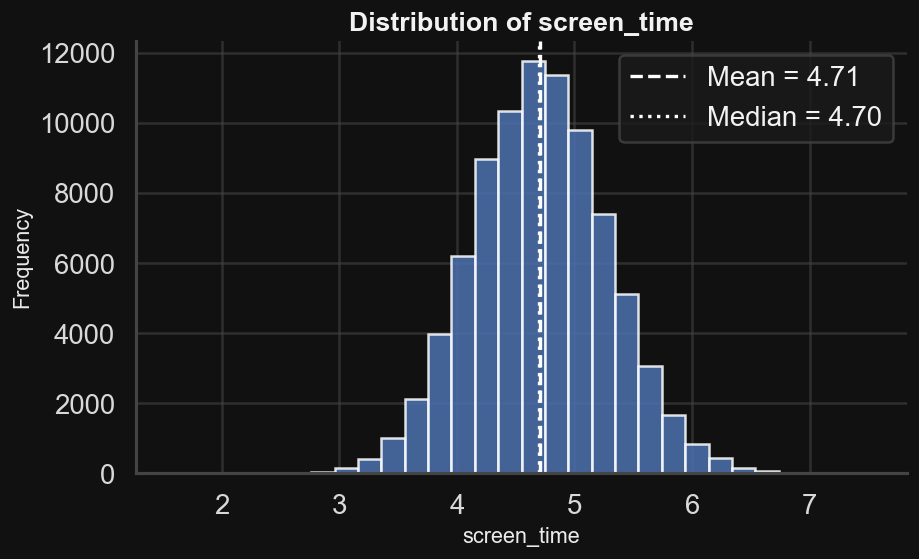

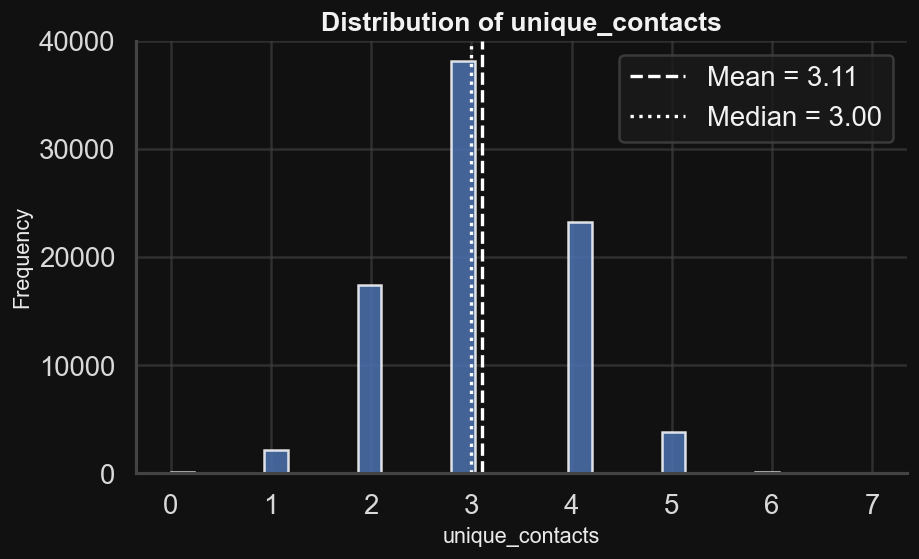

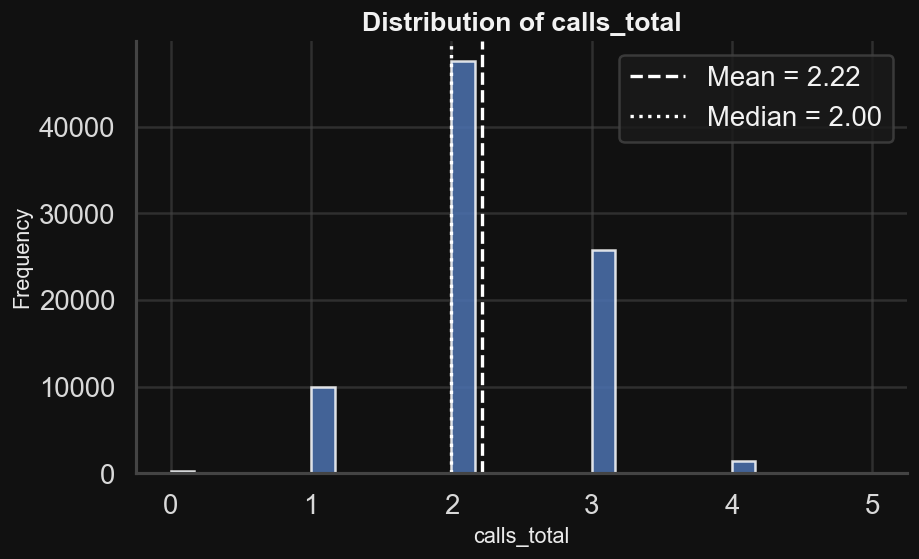

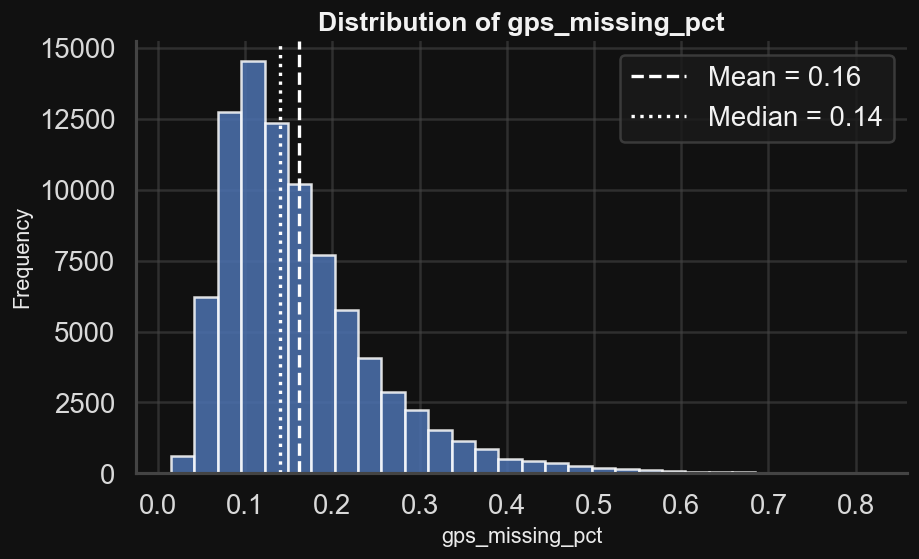

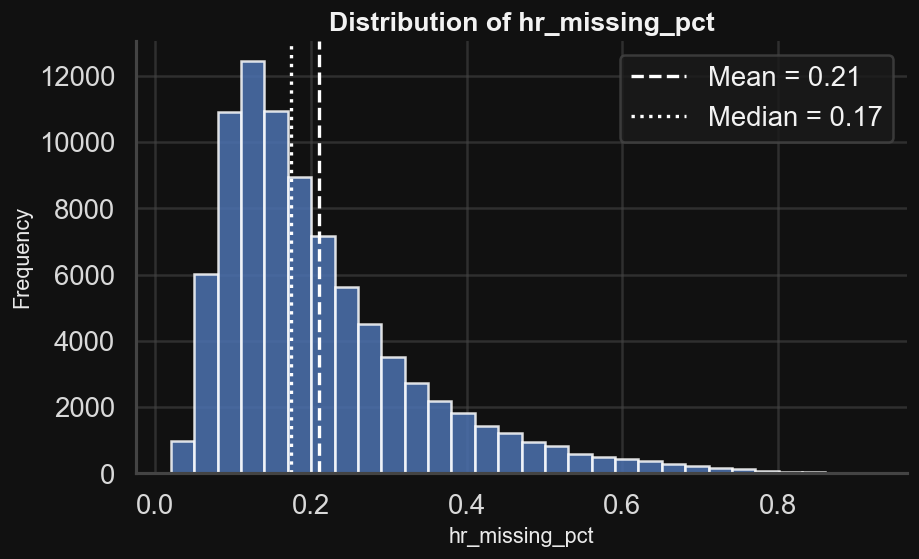

In [59]:
# ============================================================
# CELL D: DISTRIBUTION PLOTS FOR KEY VARIABLES
# ============================================================
# Purpose:
# To visually inspect whether key variables show plausible
# distributions.
# ============================================================

plot_vars = [
    "PHQ_score",
    "baseline_phq_score",
    "sleep_efficiency",
    "WASO_min",
    "steps",
    "sedentary_min",
    "active_min",
    "avg_hrv",
    "night_hrv",
    "avg_hrv_or_night_hrv",
    "resting_hr",
    "time_at_home",
    "location_entropy",
    "distance_traveled",
    "night_screen_time",
    "screen_time",
    "unique_contacts",
    "calls_total",
    "call_duration",
    "gps_missing_pct",
    "hr_missing_pct"
]

plot_vars = [
    var for var in plot_vars
    if var in analysis_df.columns and pd.api.types.is_numeric_dtype(analysis_df[var])
]

for var in plot_vars:
    values = analysis_df[var].dropna()

    if len(values) > 0:
        mean_val = values.mean()
        median_val = values.median()

        plt.figure(figsize=(8, 5))
        plt.hist(values, bins=30, alpha=0.85, edgecolor="white")
        plt.axvline(mean_val, linestyle="--", linewidth=2, label=f"Mean = {mean_val:.2f}")
        plt.axvline(median_val, linestyle=":", linewidth=2, label=f"Median = {median_val:.2f}")
        plt.title(f"Distribution of {var}")
        plt.xlabel(var)
        plt.ylabel("Frequency")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"outputs/plots/distribution_{var}.png", dpi=300)
        plt.show()

,PHQ_score,baseline_phq_score,sleep_efficiency,WASO_min,steps,sedentary_min,avg_hrv,resting_hr,time_at_home,location_entropy,night_screen_time,screen_time,unique_contacts,calls_total,gps_missing_pct,hr_missing_pct
PHQ_score,1.000000,0.745043,-0.668681,0.556066,-0.377410,0.600615,-0.559140,0.440527,0.341966,-0.587755,0.744219,0.360875,-0.357325,-0.206789,0.201181,0.215281
baseline_phq_score,0.745043,1.000000,-0.526054,0.432789,-0.011513,0.252989,-0.281163,0.241603,0.270488,-0.208379,0.600012,0.280369,-0.214614,-0.123706,0.137865,0.150219
sleep_efficiency,-0.668681,-0.526054,1.000000,-0.494170,0.277401,-0.455292,0.412500,-0.338909,-0.247726,0.427238,-0.608707,-0.279420,0.261465,0.159030,-0.145608,-0.157286
WASO_min,0.556066,0.432789,-0.494170,1.000000,-0.227526,0.364178,-0.335863,0.270261,0.223884,-0.346118,0.514182,0.242395,-0.211299,-0.125344,0.136563,0.145419
steps,-0.377410,-0.011513,0.277401,-0.227526,1.000000,-0.530375,0.438515,-0.329347,-0.151904,0.535396,-0.277476,-0.179979,0.221235,0.143119,-0.078065,-0.076404
sedentary_min,0.600615,0.252989,-0.455292,0.364178,-0.530375,1.000000,-0.543574,0.420529,0.233184,-0.624628,0.467558,0.271519,-0.304068,-0.186988,0.143634,0.141157
avg_hrv,-0.559140,-0.281163,0.412500,-0.335863,0.438515,-0.543574,1.000000,-0.366609,-0.211729,0.526888,-0.431024,-0.243334,0.265980,0.160131,-0.115452,-0.117422
resting_hr,0.440527,0.241603,-0.338909,0.270261,-0.329347,0.420529,-0.366609,1.000000,0.176738,-0.415278,0.352900,0.195751,-0.213819,-0.124607,0.108153,0.106558
time_at_home,0.341966,0.270488,-0.247726,0.223884,-0.151904,0.233184,-0.211729,0.176738,1.000000,-0.261983,0.288904,0.153338,-0.180645,-0.115043,0.111438,0.116638
location_entropy,-0.587755,-0.208379,0.427238,-0.346118,0.535396,-0.624628,0.526888,-0.415278,-0.261983,1.000000,-0.441199,-0.256203,0.358138,0.225454,-0.139884,-0.135402


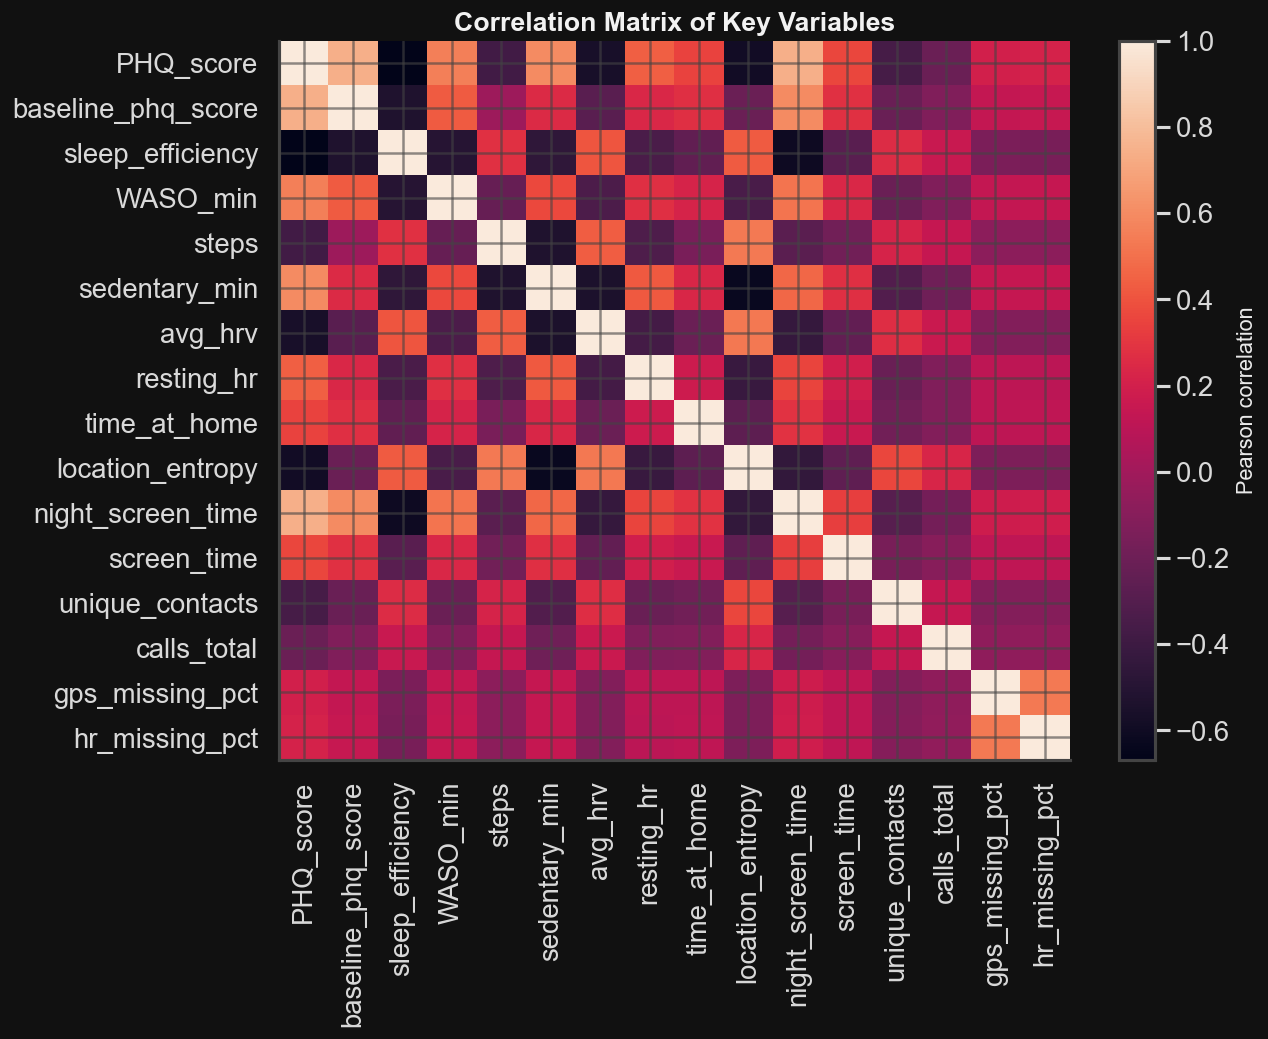

In [60]:
# ============================================================
# CELL E: CORRELATION ANALYSIS
# ============================================================
# Purpose:
# To examine whether relationships among variables are consistent
# with expected clinical and behavioral assumptions.
# ============================================================

correlation_vars = [
    "PHQ_score",
    "baseline_phq_score",
    "sleep_efficiency",
    "WASO_min",
    "steps",
    "sedentary_min",
    "active_min",
    "avg_hrv",
    "night_hrv",
    "avg_hrv_or_night_hrv",
    "resting_hr",
    "time_at_home",
    "location_entropy",
    "distance_traveled",
    "night_screen_time",
    "screen_time",
    "unique_contacts",
    "calls_total",
    "call_duration",
    "gps_missing_pct",
    "hr_missing_pct"
]

correlation_vars = [
    var for var in correlation_vars
    if var in analysis_df.columns and pd.api.types.is_numeric_dtype(analysis_df[var])
]

corr_matrix = analysis_df[correlation_vars].corr(method="pearson")

display(corr_matrix)

corr_matrix.to_csv("outputs/correlation_matrix.csv")

plt.figure(figsize=(11, 9))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix of Key Variables")
plt.tight_layout()
plt.savefig("outputs/plots/correlation_heatmap.png", dpi=300)
plt.show()

In [61]:
# ============================================================
# CELL F: SELECTED CLINICALLY MEANINGFUL CORRELATIONS
# ============================================================
# Purpose:
# To extract specific relationships that are clinically meaningful
# for MDD treatment-response monitoring.
# ============================================================

expected_relationships = [
    ("PHQ_score", "steps"),
    ("PHQ_score", "sedentary_min"),
    ("PHQ_score", "sleep_efficiency"),
    ("PHQ_score", "WASO_min"),
    ("PHQ_score", "time_at_home"),
    ("PHQ_score", "location_entropy"),
    ("PHQ_score", "night_screen_time"),
    ("PHQ_score", "screen_time"),
    ("PHQ_score", "avg_hrv"),
    ("PHQ_score", "night_hrv"),
    ("PHQ_score", "avg_hrv_or_night_hrv"),
    ("PHQ_score", "resting_hr"),
    ("PHQ_score", "unique_contacts"),

    ("sleep_efficiency", "steps"),
    ("sleep_efficiency", "sedentary_min"),
    ("steps", "sedentary_min"),
    ("time_at_home", "location_entropy"),
    ("night_screen_time", "sleep_efficiency"),
    ("gps_missing_pct", "distance_traveled"),
    ("hr_missing_pct", "avg_hrv")
]

relationship_rows = []

for var1, var2 in expected_relationships:
    if var1 in analysis_df.columns and var2 in analysis_df.columns:
        if pd.api.types.is_numeric_dtype(analysis_df[var1]) and pd.api.types.is_numeric_dtype(analysis_df[var2]):
            temp = analysis_df[[var1, var2]].dropna()

            if len(temp) > 2:
                corr_value = temp.corr().iloc[0, 1]
                relationship_rows.append({
                    "variable_1": var1,
                    "variable_2": var2,
                    "pearson_correlation": corr_value,
                    "n_used": len(temp)
                })

selected_correlations = pd.DataFrame(relationship_rows)

display(selected_correlations)

selected_correlations.to_csv("outputs/selected_clinically_meaningful_correlations.csv", index=False)

,variable_1,variable_2,pearson_correlation,n_used
0,PHQ_score,steps,-0.377410,43000
1,PHQ_score,sedentary_min,0.600615,43000
2,PHQ_score,sleep_efficiency,-0.668681,43000
3,PHQ_score,WASO_min,0.556066,43000
4,PHQ_score,time_at_home,0.341966,43000
5,PHQ_score,location_entropy,-0.587755,43000
6,PHQ_score,night_screen_time,0.744219,43000
7,PHQ_score,screen_time,0.360875,43000
8,PHQ_score,avg_hrv,-0.559140,43000
9,PHQ_score,resting_hr,0.440527,43000


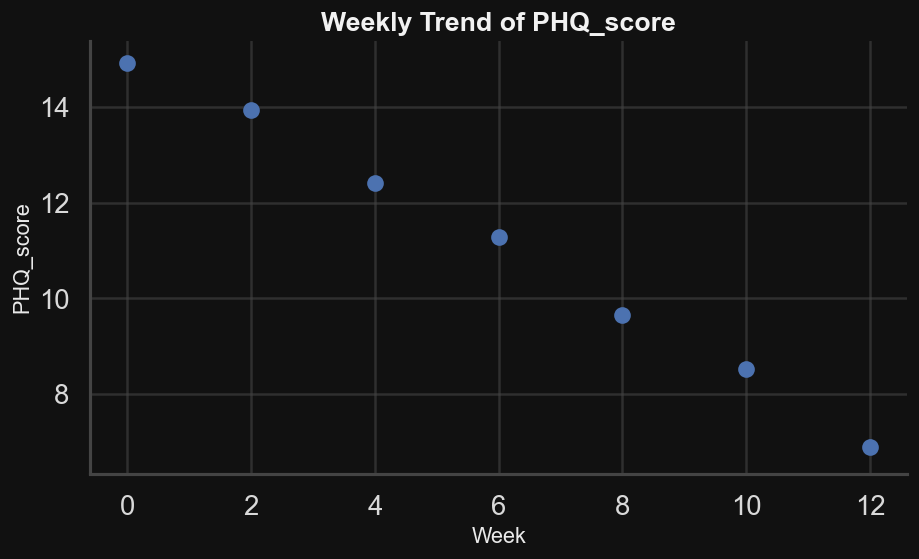

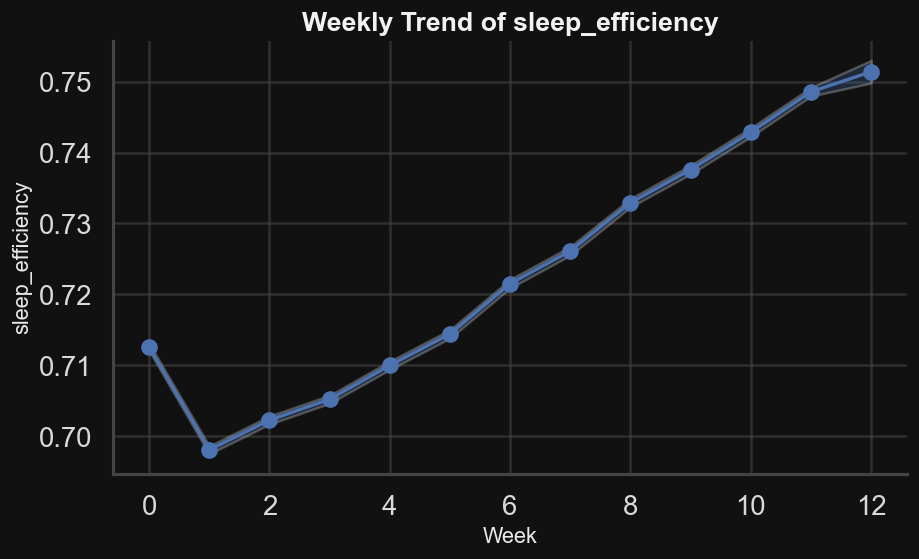

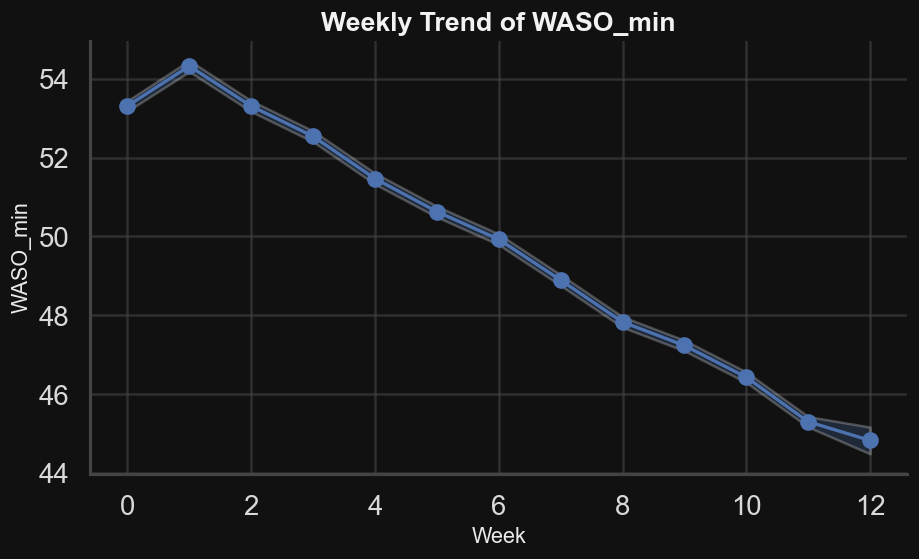

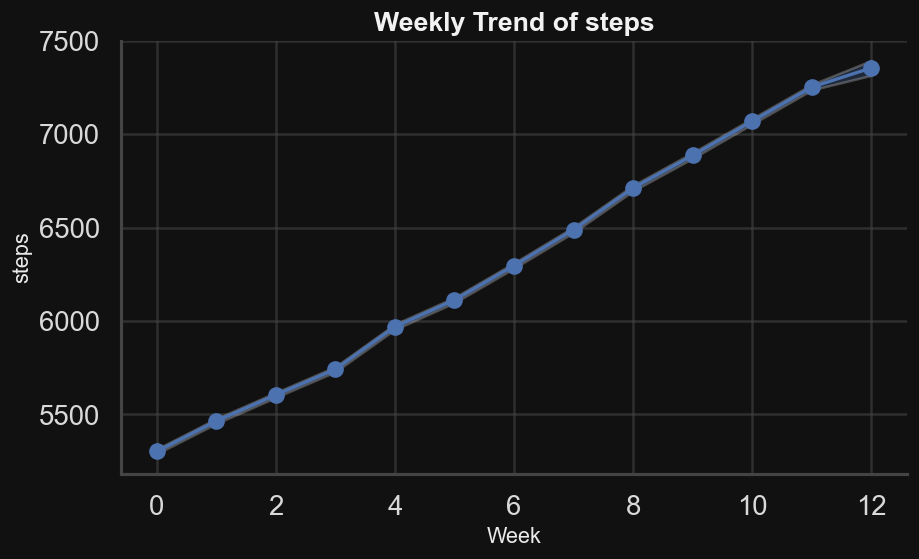

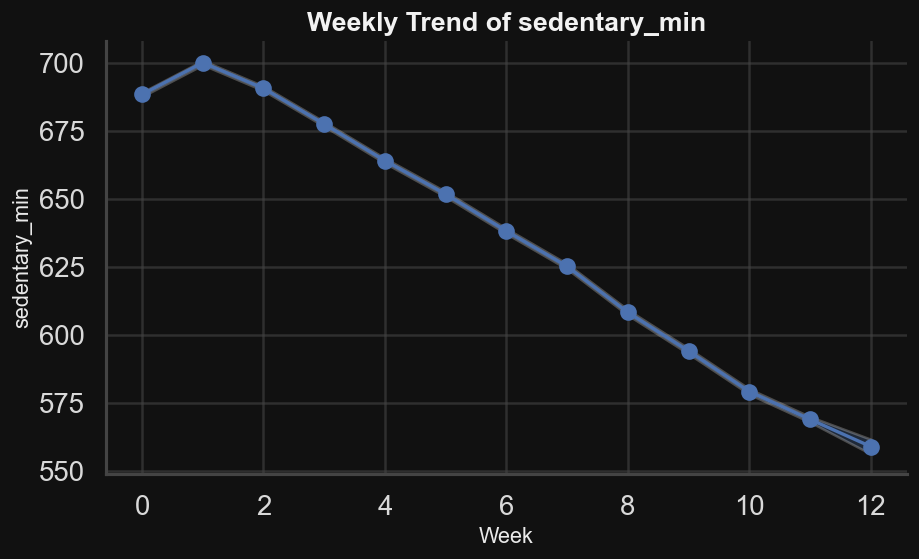

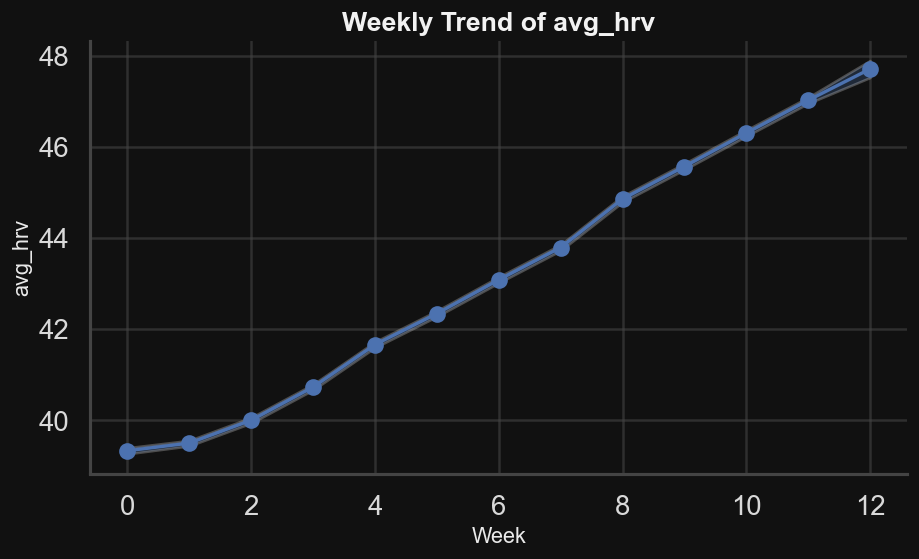

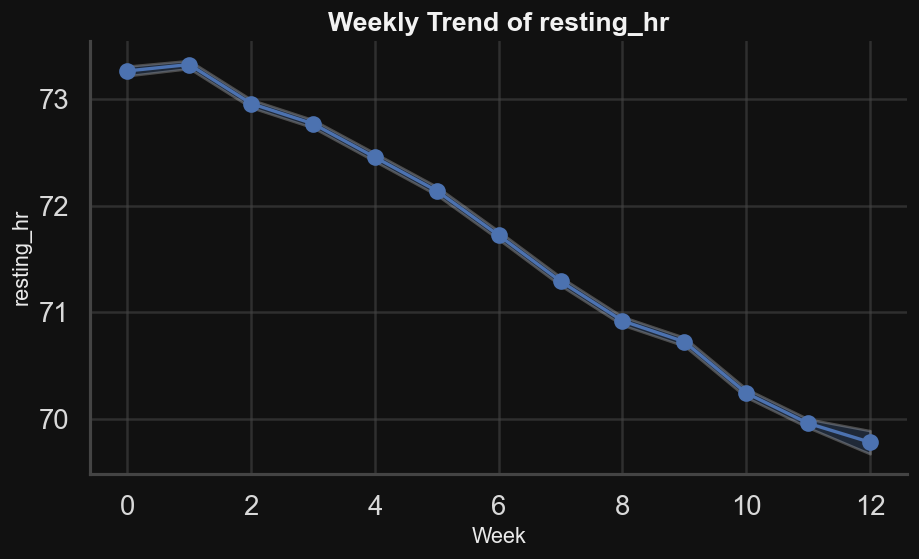

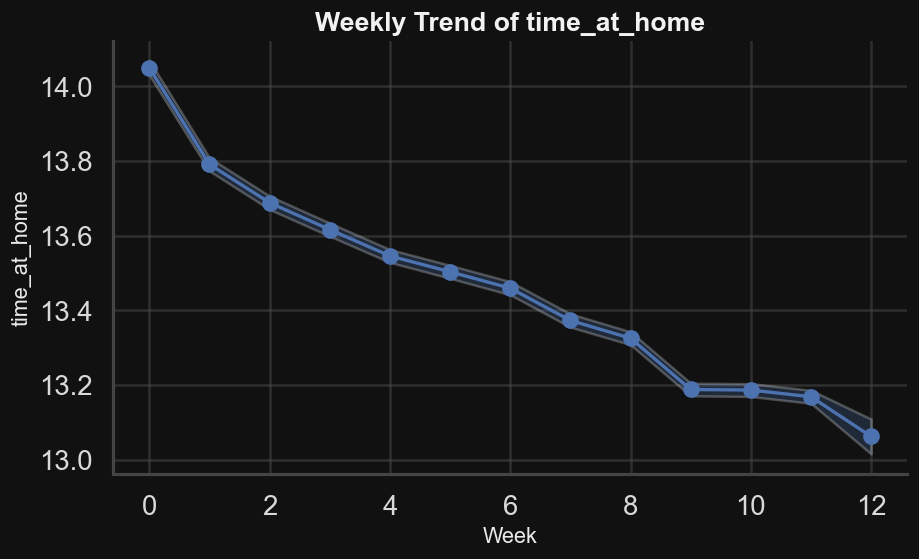

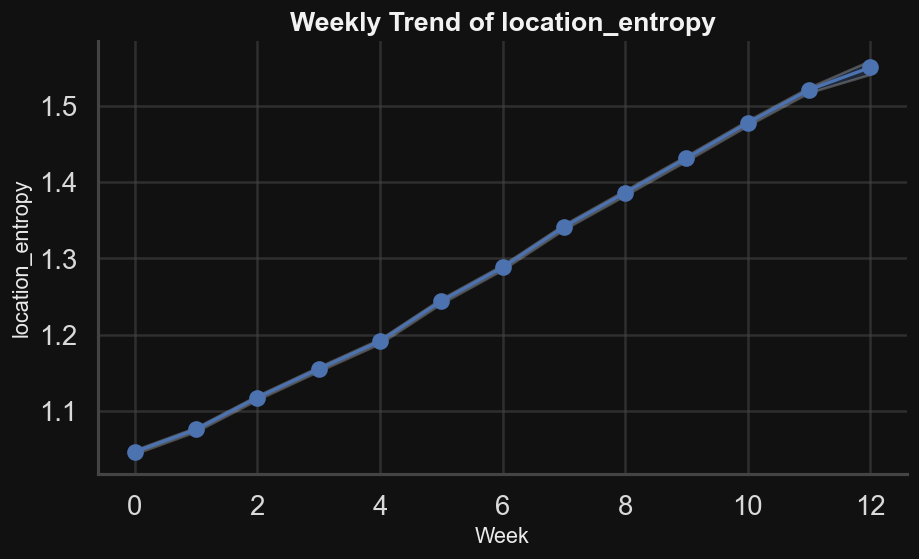

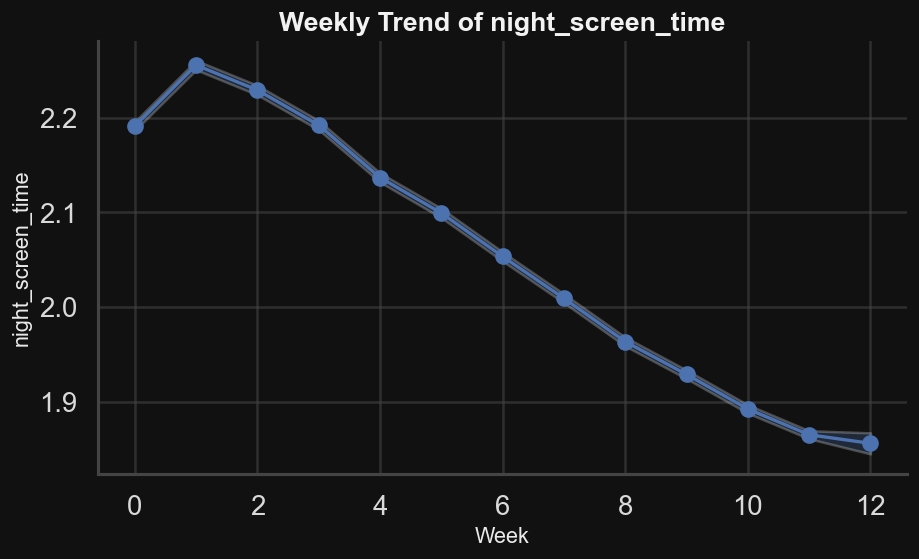

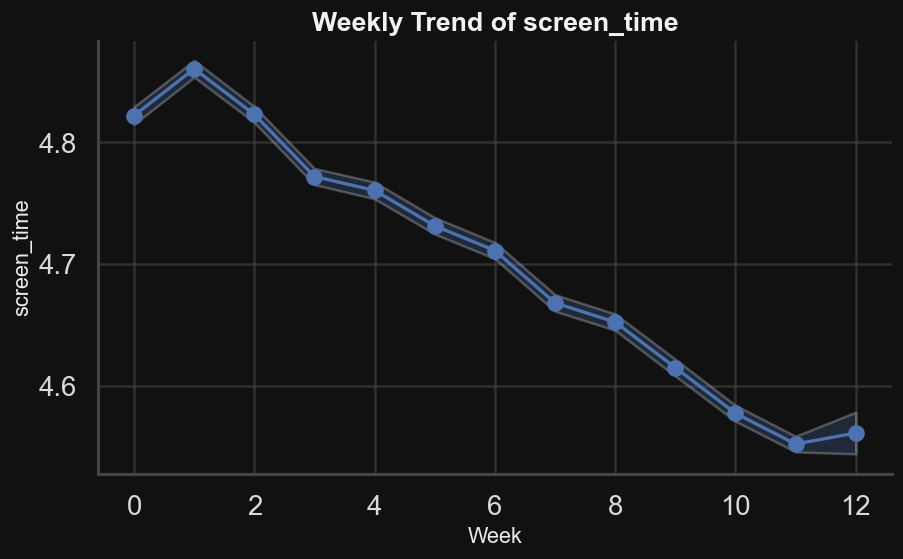

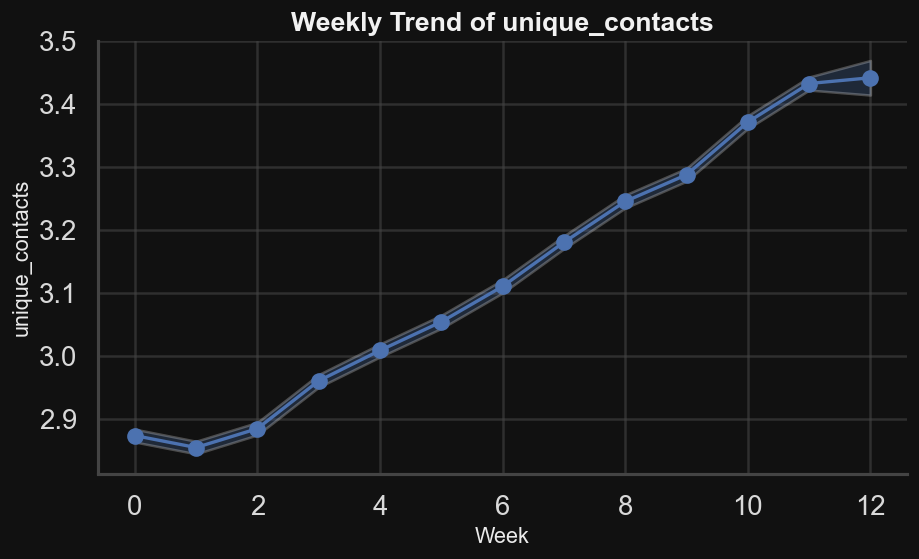

,week,mean,std,count,median,standard_error,variable
0,0,14.9259,4.100029,7000,14.8,0.049005,PHQ_score
1,1,NaN,NaN,0,NaN,NaN,PHQ_score
2,2,13.9371,4.205661,7000,13.8,0.050267,PHQ_score
3,3,NaN,NaN,0,NaN,NaN,PHQ_score
4,4,12.4222,4.488700,7000,12.4,0.053650,PHQ_score


In [63]:
# ============================================================
# CELL G: LONGITUDINAL TRAJECTORY PLOTS
# ============================================================
# Purpose:
# To assess symptom progression and behavioral change over time.
# ============================================================

trajectory_vars = [
    "PHQ_score",
    "sleep_efficiency",
    "WASO_min",
    "steps",
    "sedentary_min",
    "active_min",
    "avg_hrv",
    "night_hrv",
    "avg_hrv_or_night_hrv",
    "resting_hr",
    "time_at_home",
    "location_entropy",
    "distance_traveled",
    "night_screen_time",
    "screen_time",
    "unique_contacts"
]

trajectory_vars = [
    var for var in trajectory_vars
    if var in analysis_df.columns and pd.api.types.is_numeric_dtype(analysis_df[var])
]

if "week" not in analysis_df.columns:
    raise ValueError("The merged analysis_df does not contain a 'week' column.")

trajectory_summary_rows = []

for var in trajectory_vars:
    weekly_summary = (
        analysis_df.groupby("week")[var]
        .agg(["mean", "std", "count", "median"])
        .reset_index()
    )

    weekly_summary["standard_error"] = weekly_summary["std"] / np.sqrt(weekly_summary["count"])
    weekly_summary["variable"] = var

    trajectory_summary_rows.append(weekly_summary)

    plt.figure(figsize=(8, 5))
    plt.plot(weekly_summary["week"], weekly_summary["mean"], marker="o", linewidth=2)
    plt.fill_between(
        weekly_summary["week"],
        weekly_summary["mean"] - weekly_summary["standard_error"],
        weekly_summary["mean"] + weekly_summary["standard_error"],
        alpha=0.25
    )
    plt.title(f"Weekly Trend of {var}")
    plt.xlabel("Week")
    plt.ylabel(var)
    plt.tight_layout()
    plt.savefig(f"outputs/plots/weekly_trend_{var}.png", dpi=300)
    plt.show()

trajectory_summary = pd.concat(trajectory_summary_rows, ignore_index=True)

display(trajectory_summary.head())

trajectory_summary.to_csv("outputs/weekly_trajectory_summary.csv", index=False)

In [64]:
# ============================================================
# CELL H: IDENTIFY RESPONDER GROUP COLUMN
# ============================================================
# Purpose:
# To automatically identify which column represents responder
# or trajectory grouping.
# ============================================================

possible_group_cols = [
    "trajectory_group",
    "final_response_status",
    "response_status"
]

group_col = None

for col in possible_group_cols:
    if col in analysis_df.columns:
        group_col = col
        break

print("Responder group column used:", group_col)

if group_col is None:
    raise ValueError("No responder group column found in analysis_df.")

Responder group column used: trajectory_group


In [65]:
# ============================================================
# CELL I: RESPONDER GROUP COUNTS
# ============================================================
# Purpose:
# To check whether early responders, late responders, partial
# responders, non-responders, and unstable responders are present.
# ============================================================

if "participant_id" in analysis_df.columns:
    responder_counts = (
        analysis_df[[group_col, "participant_id"]]
        .dropna()
        .drop_duplicates()
        .groupby(group_col)
        .size()
        .reset_index(name="number_of_participants")
    )
else:
    responder_counts = (
        analysis_df[[group_col]]
        .dropna()
        .value_counts()
        .reset_index(name="number_of_records")
    )

if "number_of_participants" in responder_counts.columns:
    responder_counts["percentage"] = (
        responder_counts["number_of_participants"] /
        responder_counts["number_of_participants"].sum() * 100
    )

display(responder_counts)

responder_counts.to_csv("outputs/responder_group_counts.csv", index=False)

,trajectory_group,number_of_participants,percentage
0,delayed_responder,197,19.7
1,early_responder,235,23.5
2,non_responder,182,18.2
3,partial_responder,235,23.5
4,unstable_responder,151,15.1


,trajectory_group,week,mean,std,count,median,standard_error
0,delayed_responder,0,14.954822,4.458487,1379,14.70,0.120062
1,delayed_responder,2,14.485279,4.324842,1379,14.40,0.116463
2,delayed_responder,4,13.393401,4.433691,1379,13.00,0.119394
3,delayed_responder,6,11.177157,4.444211,1379,10.80,0.119678
4,delayed_responder,8,8.159391,4.379425,1379,7.90,0.117933
5,delayed_responder,10,5.826396,3.996931,1379,5.80,0.107633
6,delayed_responder,12,3.867005,3.751704,197,3.00,0.267298
7,early_responder,0,14.674043,3.809845,1645,14.90,0.093934
8,early_responder,2,12.380000,3.901997,1645,12.70,0.096206
9,early_responder,4,9.522979,3.767478,1645,9.80,0.092890


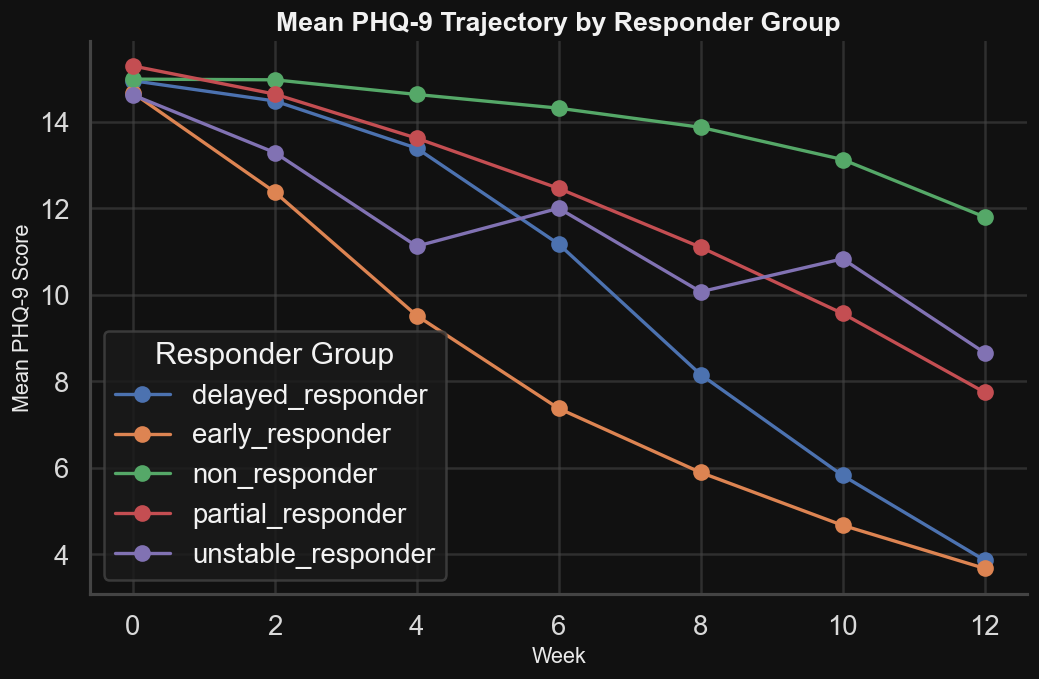

In [66]:
# ============================================================
# CELL J: PHQ-9 TRAJECTORIES BY RESPONDER GROUP
# ============================================================
# Purpose:
# To assess whether responder groups show distinct symptom
# progression trajectories.
# ============================================================

if "PHQ_score" not in analysis_df.columns:
    raise ValueError("PHQ_score not found in analysis_df.")

group_trajectory = (
    analysis_df.dropna(subset=[group_col, "PHQ_score"])
    .groupby([group_col, "week"])["PHQ_score"]
    .agg(["mean", "std", "count", "median"])
    .reset_index()
)

group_trajectory["standard_error"] = group_trajectory["std"] / np.sqrt(group_trajectory["count"])

display(group_trajectory)

group_trajectory.to_csv("outputs/phq9_trajectory_by_responder_group.csv", index=False)

plt.figure(figsize=(9, 6))

for group_name, group_data in group_trajectory.groupby(group_col):
    plt.plot(
        group_data["week"],
        group_data["mean"],
        marker="o",
        linewidth=2,
        label=str(group_name)
    )

plt.title("Mean PHQ-9 Trajectory by Responder Group")
plt.xlabel("Week")
plt.ylabel("Mean PHQ-9 Score")
plt.legend(title="Responder Group")
plt.tight_layout()
plt.savefig("outputs/plots/phq9_trajectory_by_responder_group.png", dpi=300)
plt.show()

In [67]:
# ============================================================
# CELL K: BEHAVIORAL PROFILES BY RESPONDER GROUP
# ============================================================
# Purpose:
# To compare sleep, activity, mobility, physiology, and digital
# behavior across responder groups.
# ============================================================

behavior_profile_vars = [
    "sleep_efficiency",
    "WASO_min",
    "steps",
    "sedentary_min",
    "active_min",
    "avg_hrv",
    "night_hrv",
    "avg_hrv_or_night_hrv",
    "resting_hr",
    "time_at_home",
    "location_entropy",
    "distance_traveled",
    "night_screen_time",
    "screen_time",
    "unique_contacts",
    "calls_total",
    "call_duration"
]

behavior_profile_vars = [
    var for var in behavior_profile_vars
    if var in analysis_df.columns and pd.api.types.is_numeric_dtype(analysis_df[var])
]

behavior_by_group = (
    analysis_df.dropna(subset=[group_col])
    .groupby(group_col)[behavior_profile_vars]
    .agg(["mean", "std", "median"])
)

display(behavior_by_group)

behavior_by_group.to_csv("outputs/behavioral_profiles_by_responder_group.csv")

sleep_efficiency                    WASO_min             \
                               mean       std median       mean        std   
trajectory_group                                                             
delayed_responder          0.724609  0.050271  0.725  49.882812  11.573527   
early_responder            0.739777  0.050344  0.740  46.844463  10.966354   
non_responder              0.703550  0.047683  0.706  53.206338  11.936185   
partial_responder          0.713720  0.048859  0.714  51.564810  11.386485   
unstable_responder         0.719990  0.047083  0.720  50.414662  10.968704   

                                 steps                      sedentary_min  \
                   median         mean          std  median          mean   
trajectory_group                                                            
delayed_responder    49.7  6245.518121  1384.510855  6237.0    637.476567   
early_responder      46.8  6729.010292  1428.790062  6742.0    602.406333   
non_responder        52.9  5677.683363  1145.650365  5669.0    679.883338   
partial_responder    51.2  6053.960910  1239.350914  6048.0    654.451361   
unstable_responder   50.0  6086.032651  1188.563851  6069.0    649.170029   

                                        avg_hrv                  resting_hr  \
                          std median       mean       std median       mean   
trajectory_group                                                              
delayed_responder   92.454011  641.0  43.022158  6.435755   43.1  71.787109   
early_responder     93.033857  600.0  45.007066  6.341207   45.3  70.847590   
non_responder       71.780838  679.0  40.354907  5.284296   40.3  72.869780   
partial_responder   79.849117  657.0  42.059664  5.682354   42.1  72.228164   
unstable_responder  75.529230  649.0  42.248421  5.610793   42.3  71.852410   

                                    time_at_home                   \
                         std median         mean       std median   
trajectory_group                                                    
delayed_responder   3.546570   71.7    13.517609  1.504972  13.50   
early_responder     3.631145   70.8    13.324307  1.489113  13.31   
non_responder       3.369807   72.8    13.760847  1.516977  13.75   
partial_responder   3.436744   72.2    13.581923  1.506021  13.53   
unstable_responder  3.411873   71.8    13.517191  1.512394  13.47   

                   location_entropy                  night_screen_time  \
                               mean       std median              mean   
trajectory_group                                                         
delayed_responder          1.272227  0.312003  1.259          2.058586   
early_responder            1.396258  0.328403  1.403          1.923959   
non_responder              1.114614  0.245234  1.117          2.224169   
partial_responder          1.223581  0.271712  1.218          2.117296   
unstable_responder         1.251410  0.258209  1.251          2.069738   

                                    screen_time                   \
                         std median        mean       std median   
trajectory_group                                                   
delayed_responder   0.410345  2.010    4.719486  0.570247   4.71   
early_responder     0.365515  1.880    4.605997  0.556906   4.60   
non_responder       0.429409  2.185    4.839775  0.589709   4.83   
partial_responder   0.404671  2.090    4.755076  0.563056   4.75   
unstable_responder  0.392118  2.040    4.702723  0.556083   4.69   

                   unique_contacts                  calls_total            \
                              mean       std median        mean       std   
trajectory_group                                                            
delayed_responder         3.090780  0.880672    3.0    2.216621  0.681818   
early_responder           3.290054  0.881478    3.0    2.290450  0.680759   
non_responder             2.868771  0.866577    3.0    2.118707  0.6

In [68]:
# ============================================================
# CELL L: MISSINGNESS CHECKS ACROSS ALL DATASETS
# ============================================================
# Purpose:
# To assess whether missing data patterns are present but not
# excessive or unrealistic.
# ============================================================

missingness_all = []

for dataset_name, dataset in datasets.items():
    missing_table = pd.DataFrame({
        "dataset": dataset_name,
        "variable": dataset.columns,
        "missing_count": dataset.isna().sum().values,
        "missing_pct": (dataset.isna().mean() * 100).values,
        "non_missing_count": dataset.notna().sum().values
    })

    missingness_all.append(missing_table)

missingness_summary = pd.concat(missingness_all, ignore_index=True)
missingness_summary = missingness_summary.sort_values(
    ["dataset", "missing_pct"],
    ascending=[True, False]
)

display(missingness_summary)

missingness_summary.to_csv("outputs/missingness_summary_all_datasets.csv", index=False)

,dataset,variable,missing_count,missing_pct,non_missing_count
68,clinical_assessments,treatment_review_decision,4000,57.142857,3000
59,clinical_assessments,participant_id,0,0.000000,7000
60,clinical_assessments,assessment_date,0,0.000000,7000
61,clinical_assessments,week,0,0.000000,7000
62,clinical_assessments,PHQ_score,0,0.000000,7000
...,...,...,...,...,...
82,weekly_summary,week,0,0.000000,13
83,weekly_summary,mean,0,0.000000,13
84,weekly_summary,std,0,0.000000,13
85,weekly_summary,count,0,0.000000,13


In [69]:
# ============================================================
# CELL M: MISSINGNESS OVER TIME
# ============================================================
# Purpose:
# To check whether missingness changes across the monitoring weeks.
# ============================================================

if "week" in daily_data.columns:
    missing_by_week = daily_data.groupby("week").apply(lambda x: x.isna().mean() * 100)

    display(missing_by_week)

    missing_by_week.to_csv("outputs/missingness_by_week_daily_data.csv")
else:
    print("No 'week' column found in daily_data.")

,participant_id,date,study_day,day_of_week,is_weekend,life_event_flag,ema_anhedonia,ema_energy,ema_stress,sleep_efficiency,WASO_min,avg_hrv,resting_hr,steps,sedentary_min,time_at_home,location_entropy,distance_traveled_km,bedtime_variability_min,wake_variability_min,screen_time,night_screen_time,app_sessions_total,app_sessions_social,unique_contacts,calls_total,call_duration_min,med_adherence,therapy_adherence,overall_adherence,gps_missing_pct,hr_missing_pct,gps_outage_flag,wearable_nonwear_flag,passive_dropout_flag
week,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.6,30.3,0.0,0.0,0.0,0.0,0.0,0.0


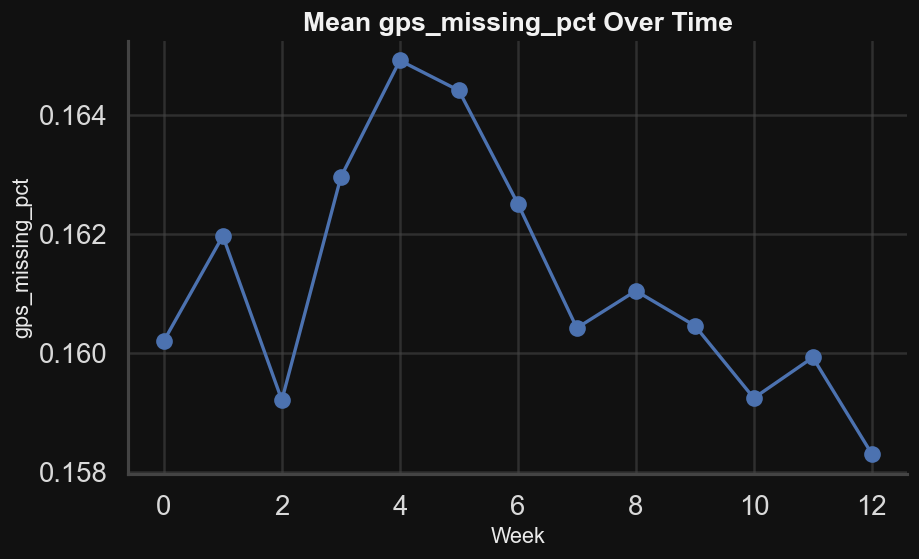

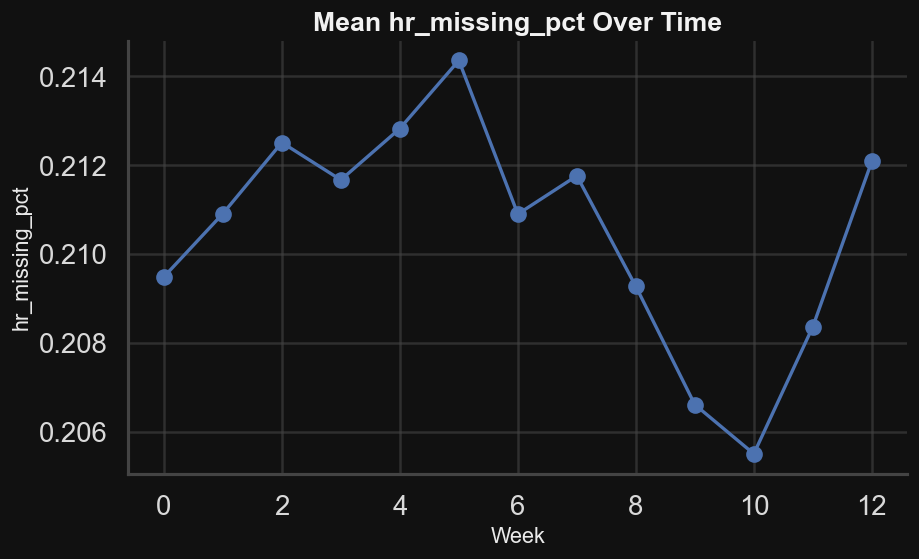

In [70]:
# ============================================================
# CELL N: SENSOR MISSINGNESS OVER TIME
# ============================================================
# Purpose:
# To inspect GPS and heart-rate missingness trends over time.
# ============================================================

sensor_missing_vars = [
    "gps_missing_pct",
    "hr_missing_pct"
]

sensor_missing_vars = [
    var for var in sensor_missing_vars
    if var in daily_data.columns and pd.api.types.is_numeric_dtype(daily_data[var])
]

if "week" in daily_data.columns and len(sensor_missing_vars) > 0:
    for var in sensor_missing_vars:
        weekly_sensor_missing = (
            daily_data.groupby("week")[var]
            .mean()
            .reset_index()
        )

        plt.figure(figsize=(8, 5))
        plt.plot(
            weekly_sensor_missing["week"],
            weekly_sensor_missing[var],
            marker="o",
            linewidth=2
        )
        plt.title(f"Mean {var} Over Time")
        plt.xlabel("Week")
        plt.ylabel(var)
        plt.tight_layout()
        plt.savefig(f"outputs/plots/weekly_{var}.png", dpi=300)
        plt.show()
else:
    print("Sensor missingness variables or week column not found.")

In [71]:
# ============================================================
# CELL O: REPORT-READY PLAUSIBILITY SUMMARY TABLE
# ============================================================
# Purpose:
# To summarize all plausibility analyses conducted.
# ============================================================

plausibility_summary = pd.DataFrame({
    "Plausibility dimension": [
        "Distribution realism",
        "Expected range plausibility",
        "Dependency realism",
        "Temporal realism",
        "Clinical realism",
        "Responder group distinction",
        "Missingness realism"
    ],
    "Analysis performed": [
        "Distribution plots and descriptive statistics for key clinical, behavioral, physiological, and digital variables",
        "Range checks for PHQ-9, sleep, activity, HRV, heart rate, mobility, screen use, and missingness indicators",
        "Correlation matrix and selected clinically meaningful pairwise relationships",
        "Weekly trajectory plots for symptoms and behavioral variables",
        "PHQ-9 trajectories by responder group",
        "Behavioral and physiological profiles compared across responder groups",
        "Overall missingness, missingness by dataset, missingness over time, and sensor missingness trends"
    ],
    "Purpose": [
        "To assess whether variables show plausible central tendencies, variation, and distributions",
        "To confirm that generated values remain within defensible clinical and behavioral ranges",
        "To examine whether relationships among variables follow expected clinical and behavioral assumptions",
        "To assess whether symptom progression and behavioral change evolve plausibly across time",
        "To assess whether response profiles show clinically meaningful symptom trajectories",
        "To evaluate whether responder groups show distinct behavioral and physiological profiles",
        "To ensure missing data patterns are present but not excessive or unrealistic"
    ]
})

display(plausibility_summary)

plausibility_summary.to_csv("outputs/report_ready_plausibility_summary.csv", index=False)

,Plausibility dimension,Analysis performed,Purpose
0,Distribution realism,Distribution plots and descriptive statistics ...,To assess whether variables show plausible cen...
1,Expected range plausibility,"Range checks for PHQ-9, sleep, activity, HRV, ...",To confirm that generated values remain within...
2,Dependency realism,Correlation matrix and selected clinically mea...,To examine whether relationships among variabl...
3,Temporal realism,Weekly trajectory plots for symptoms and behav...,To assess whether symptom progression and beha...
4,Clinical realism,PHQ-9 trajectories by responder group,To assess whether response profiles show clini...
5,Responder group distinction,Behavioral and physiological profiles compared...,To evaluate whether responder groups show dist...
6,Missingness realism,"Overall missingness, missingness by dataset, m...",To ensure missing data patterns are present bu...


In [73]:
# ============================================================
# CELL P: EXPORT KEY OUTPUTS INTO ONE EXCEL WORKBOOK
# ============================================================
# Purpose:
# To create one file you can upload later for report writing.
# ============================================================

excel_output_path = "outputs/synthetic_dataset_plausibility_analysis_results.xlsx"

with pd.ExcelWriter(excel_output_path, engine="openpyxl") as writer:
    descriptive_statistics.to_excel(writer, sheet_name="Descriptive statistics", index=False)
    range_check.to_excel(writer, sheet_name="Range checks", index=False)
    corr_matrix.to_excel(writer, sheet_name="Correlation matrix")
    selected_correlations.to_excel(writer, sheet_name="Selected correlations", index=False)
    trajectory_summary.to_excel(writer, sheet_name="Weekly trajectories", index=False)
    responder_counts.to_excel(writer, sheet_name="Responder counts", index=False)
    group_trajectory.to_excel(writer, sheet_name="PHQ by responder group", index=False)
    behavior_by_group.to_excel(writer, sheet_name="Behavior by group")
    missingness_summary.to_excel(writer, sheet_name="Missingness", index=False)
    plausibility_summary.to_excel(writer, sheet_name="Plausibility summary", index=False)

print(f"Excel file saved here: {excel_output_path}")

Excel file saved here: outputs/synthetic_dataset_plausibility_analysis_results.xlsx
